In [ ]:
import marimo as mo

> **Generated file.** This notebook is exported from its marimo source,
> `src/pipelines/02_fnd_eda_notebooks/03_redd_eda.py`.
> Edit the source and re-export; do not edit the exported notebook by hand.

# 03 · REDD — six homes, two recorders, half a clock

**Dataset:** REDD (Reference Energy Disaggregation Data Set), J. Zico Kolter and
Matthew J. Johnson, MIT SustKDD 2011 — six US households, instrumented for a few
weeks in spring 2011.
**Role in the FND lineup:** the *heritage reference*. UK-DALE (01) and REFIT (02) asked
"how much supervision does a dataset hand us?". REDD asks a harder question:
**what does the panel know that the submeters never recorded — and what does the paper
record that the panel never saw?** It is also the only corpus here whose homes are
North American split-phase services, which makes it our blueprint for two-leg physics.

> **How to read.** Every question (Q1-Q10) states its *Question* in italics, computes
> everything live from the parquet layer, and ends with a **Reading it.** interpretation.
> Nothing is hand-typed. Tags: **[collectable]** = a fact our gold layer could store or
> a rule our pipeline should adopt; **[insight only]** = context that explains behaviour
> without changing the pipeline. Companions: 01 (UK-DALE), 02/02b (REFIT), 04 (ECO),
> 05 (GREEND); cross-dataset threads (threshold rule, clock convention, attribution)
> are called out as they appear.

In [ ]:
import sys

import numpy as np
import pandas as pd

sys.path.insert(0, "src/pipelines/02_fnd_eda_notebooks")
import eda_fnd_lib as eda

eda.apply_style()

<module 'matplotlib.pyplot' from '/root/longvdh/agent_space/projects/watt-wiser/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

## Meet the dataset

REDD is the 2011 ancestor of every dataset in this series. Six real US homes, each wired
with **two recorders**: a *panel recorder* watching the split-phase service entrance at
1 s (one meter per 120 V leg), and a *circuit recorder* watching 9-24 labelled branch
circuits at 3-4 s. That two-recorder design is the source of everything interesting
below. The panel sees physics the circuits miss; the circuits see hours the panel slept
through; and the two clocks overlap for only about half of building 1's span.

What REDD does **not** have matters too: no voltage, no current, no power factor —
real power only (per the release documentation, the meters record *apparent* power, so
absolute W and kWh run high; ratios within a home are unaffected). And no kettle: the
2011 MIT release predates the kettle slot UK-DALE and REFIT fill.

In [ ]:
import glob as _glob
import re as _re

import pyarrow.parquet as _pq

amap = eda.appliance_map("redd")
files = [_f for _f in sorted(_glob.glob(str(eda.fnd_file("redd", "*.parquet")))) if ("elec_meter" in _f and "cache" not in _f)]
cache_files = [_f for _f in sorted(_glob.glob(str(eda.fnd_file("redd", "*.parquet")))) if "cache" in _f]
_total_rows = 0
_lab_rows = 0
for _f in files:
    _mb = _re.search(r"building(\d)_elec_meter(\d+)", str(_f))
    _total_rows += _pq.ParquetFile(str(_f)).metadata.num_rows
_rows = []
for _b in range(1, 7):
    _bk = "building_%d" % _b
    _met = amap["redd"][_bk]["meters"]
    _n_lab_rows = 0
    for _m in _met:
        _pf = _pq.ParquetFile(str(eda.fnd_file("redd", "building%d_elec_meter%s.parquet" % (_b, _m))))
        _n_lab_rows += _pf.metadata.num_rows
    _lab_rows += _n_lab_rows
    _rows.append(["b%d" % _b, len(amap["redd"][_bk]["site_meters"]), len(_met), eda.fmt_int(_n_lab_rows)])
_n_site = sum(len(amap["redd"]["building_%d" % _b]["site_meters"]) for _b in range(1, 7))
_rows.append(["all six", _n_site, sum(len(amap["redd"]["building_%d" % _b]["meters"]) for _b in range(1, 7)), eda.fmt_int(_lab_rows)])
mo.md(eda.md_table(["building", "panel meters", "labelled circuits", "rows (labelled)"], _rows))
print("meter files: %d (+%d NILMTK cache tables excluded from the series); rows incl. panel: %s"
      % (len(files), len(cache_files), eda.fmt_int(_total_rows)))

meter files: 116 (+31 NILMTK cache tables excluded from the series); rows incl. panel: 56,341,629


**Reading it.** 116 meters, 56.3 M rows of real power, one spring. Building 1 is the
reference home: 2 panel meters plus **18 labelled circuits**. Buildings 2-6 carry between
9 and 24 labelled circuits each. The 2011 vintage means modern switch-mode standby loads
are under-represented; REDD's enduring value is **panel physics and signature variety**,
not current load profiles. [insight only] Building 1 is also the only place where panel
and circuits can be compared event-by-event — every question below leans on it first,
then checks how far the pattern generalises.

## A day in the life (the only whole-home signal that exists)

Before any labelling question: what does a home look like at the service entrance?
Building 1's two panel meters (m1, m2) share an exact 1 s clock, so their sum is the
whole-home signal — whenever the panel recorder bothered to run. Watch the week view:
the holes are not cleaning artefacts, they are the recorder taking entire days off.

In [ ]:
m1_ts, m1_v = eda.read_channel(eda.fnd_file("redd", "building1_elec_meter1.parquet"), "value_0")
m2_ts, m2_v = eda.read_channel(eda.fnd_file("redd", "building1_elec_meter2.parquet"), "value_0")

In [ ]:
print("b1: m1 and m2 share an exact timestamp grid:", bool(np.array_equal(m1_ts, m2_ts)))
w = m1_v + m2_v

def _leg_stats(ts, v, name):
    kwh = eda.kwh_of(ts, v, missing_values=(), dt_cap_s=10.0)
    return [name, eda.fmt_int(len(v)), round(float(v.mean()), 1), round(float(np.percentile(v, 50)), 1),
            round(float(np.percentile(v, 95)), 0), round(float(kwh), 1)]

print("leg imbalance |mean1-mean2|/mean1: %.1f%%" % (100 * abs(m1_v.mean() - m2_v.mean()) / max(m1_v.mean(), 1e-9)))
mo.md(eda.md_table(["leg", "rows", "mean_W", "p50_W", "p95_W", "kWh_cap10s"],
                   [_leg_stats(m1_ts, m1_v, "m1 (leg A)"), _leg_stats(m2_ts, m2_v, "m2 (leg B)"),
                    _leg_stats(m1_ts, w, "m1+m2 (panel)")]))

b1: m1 and m2 share an exact timestamp grid: True
leg imbalance |mean1-mean2|/mean1: 30.8%


| leg | rows | mean_W | p50_W | p95_W | kWh_cap10s |
| --- | --- | --- | --- | --- | --- |
| m1 (leg A) | 1,561,660 | 226.9 | 130.2 | 385.0 | 99.2 |
| m2 (leg B) | 1,561,660 | 157.1 | 41.7 | 692.0 | 68.5 |
| m1+m2 (panel) | 1,561,660 | 384.0 | 176.3 | 1264.0 | 167.7 |

In [ ]:
scan_b1 = eda.scan_arrays(m1_ts, w, missing_values=(), local_offset_hours=-4.0)
kwh_capped = eda.kwh_of(m1_ts, w, missing_values=(), dt_cap_s=10.0)
print("energy, capped at 10 s/sample : %.1f kWh  (the honest integral)" % kwh_capped)
print("energy, uncapped left-Riemann : %.1f kWh  (bridges the outages)" % scan_b1["energy_kwh"])
print("phantom energy carried across the outages: %.1f kWh" % (scan_b1["energy_kwh"] - kwh_capped))
_dsec = np.diff(m1_ts) / 1e6
okp = (_dsec > 0) & (_dsec <= 8.0)
_dvw = np.diff(w)
span_d = (m1_ts[-1] - m1_ts[0]) / 86400e6
s100 = int((okp & (_dvw >= 100)).sum())
s300 = int((okp & (_dvw >= 300)).sum())
print("step census: %d steps >=100 W (%.1f/day of span) | %d steps >=300 W (%.1f/day)"
      % (s100, s100 / span_d, s300, s300 / span_d))
mo.md(eda.md_scan_stats(scan_b1, "REDD b1 whole panel (m1+m2), on samples where the logger ran"))

energy, capped at 10 s/sample : 167.7 kWh  (the honest integral)
energy, uncapped left-Riemann : 341.3 kWh  (bridges the outages)
phantom energy carried across the outages: 173.6 kWh
step census: 2163 steps >=100 W (59.6/day of span) | 1621 steps >=300 W (44.7/day)


| metric | value |
| --- | --- |
| series | REDD b1 whole panel (m1+m2), on samples where the logger ran |
| rows | 1,561,660 (missing 0) |
| span | 36.3 days |
| cadence | median 1.00 s, p90 1.00 s, gap fraction 0.000 |
| power W | mean 384.0, p50 176.3, p95 1263.9, p99 5967.8, max 12333 |
| energy | 341.3 kWh |
| steps per day | >=30 W 214.9, >=100 W 134.0, >=300 W 89.7 |

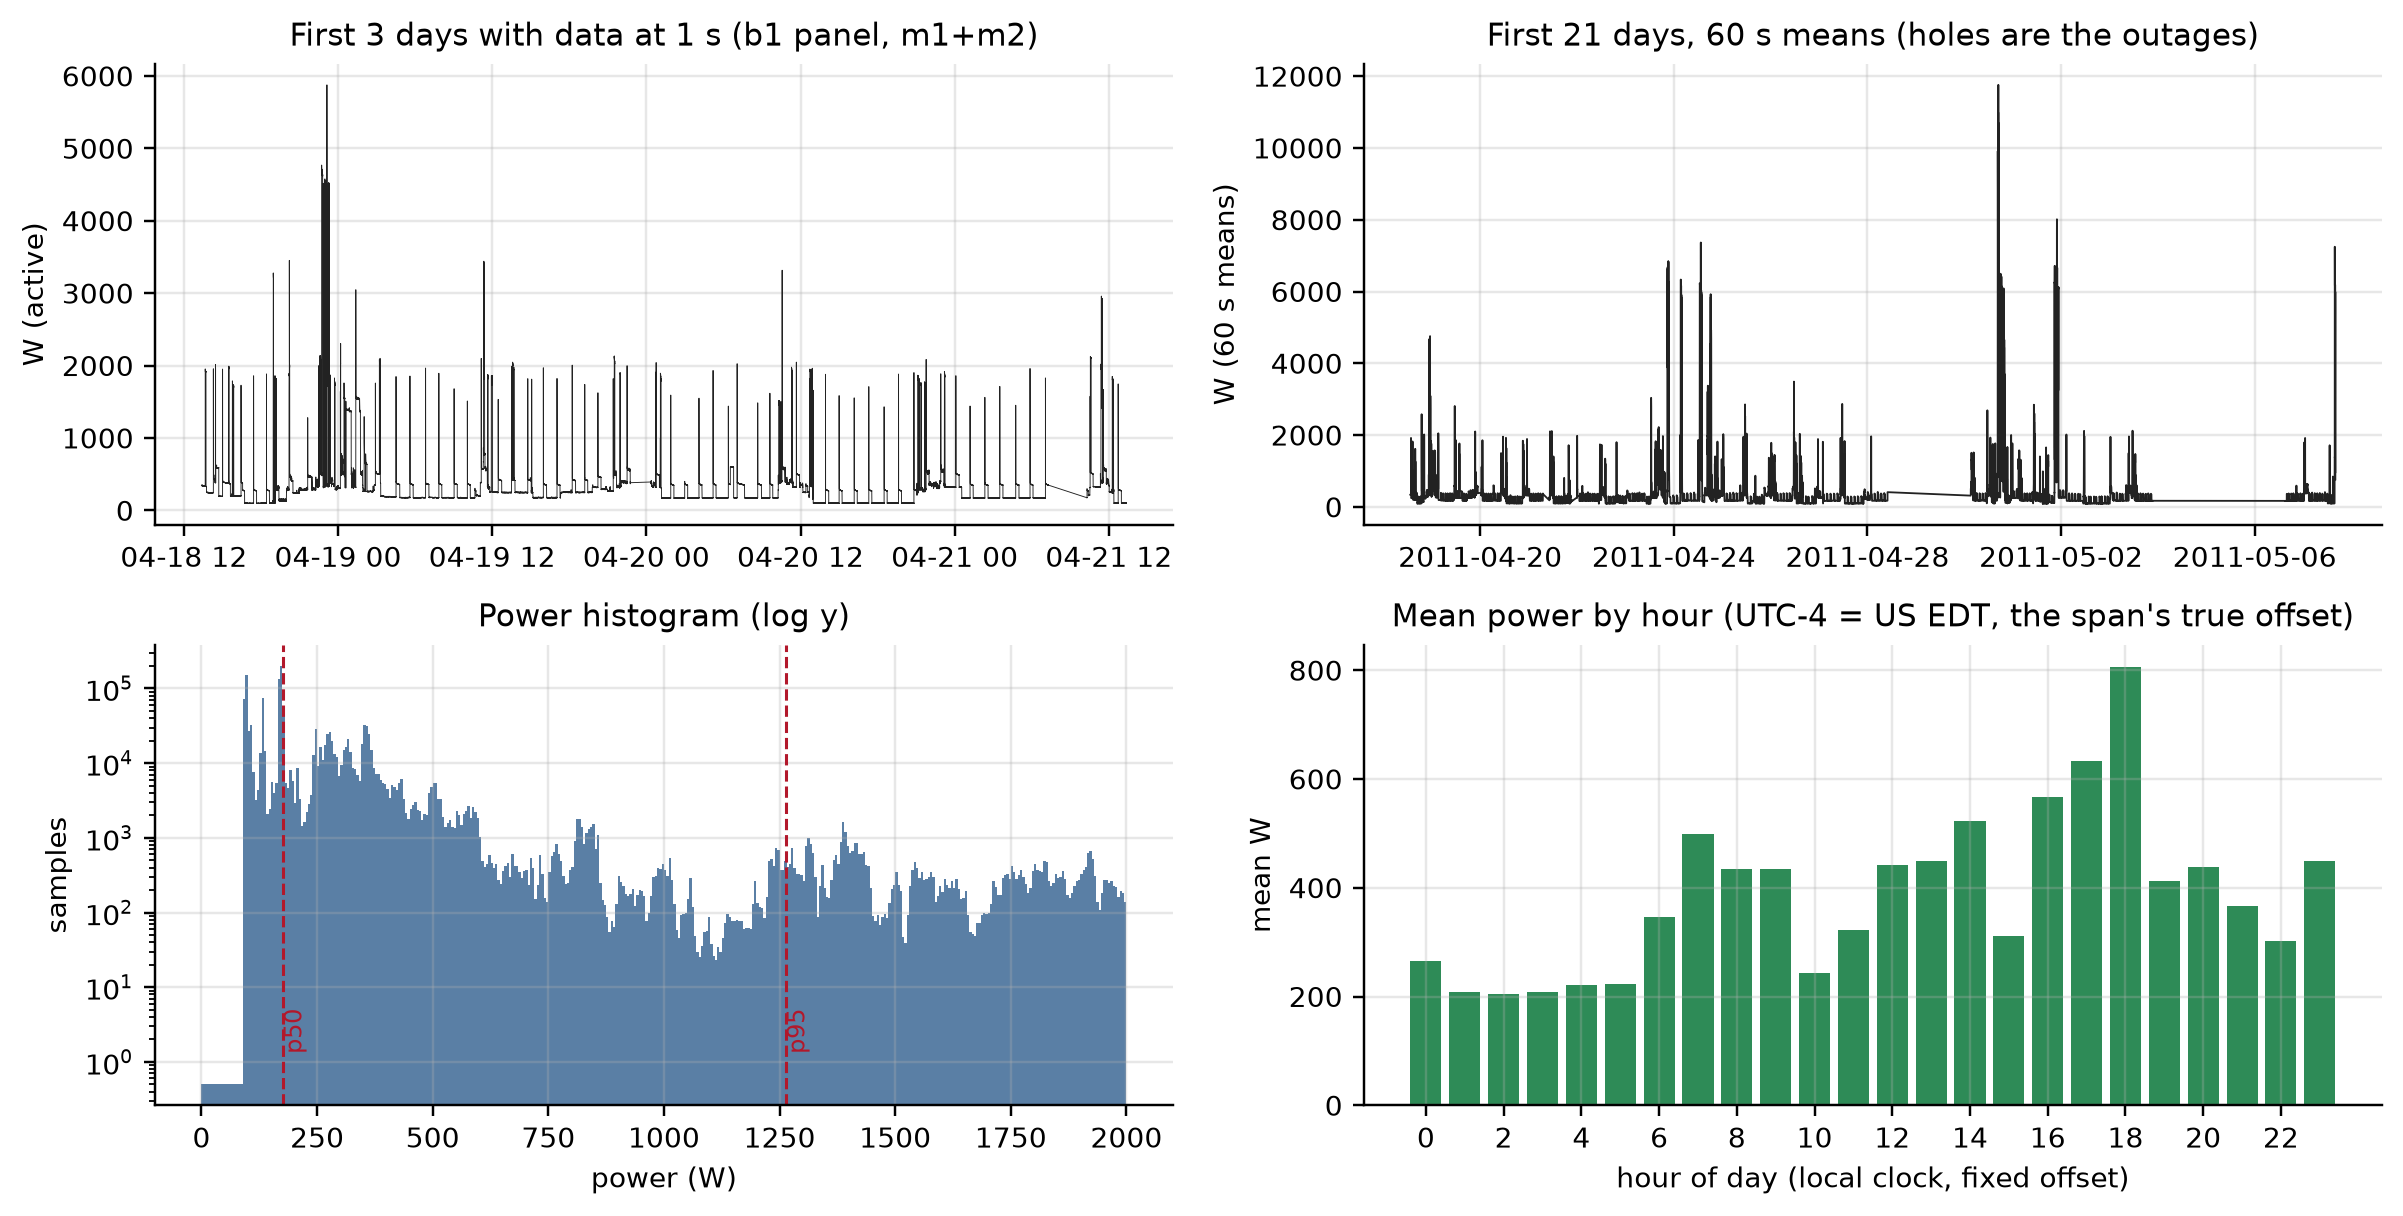

In [ ]:
import matplotlib.dates as _mdates
import matplotlib.pyplot as plt

_fig, _ax = plt.subplots(2, 2, figsize=(11, 5.6))
eda.fig_zoom(scan_b1, ax=_ax[0, 0], title="First 3 days with data at 1 s (b1 panel, m1+m2)")
eda.fig_week(scan_b1, ax=_ax[0, 1], title="First 21 days, 60 s means (holes are the outages)")
eda.fig_hist_power(scan_b1, ax=_ax[1, 0], title="Power histogram (log y)")
eda.fig_diurnal(scan_b1, ax=_ax[1, 1], title="Mean power by hour (UTC-4 = US EDT, the span's true offset)")
_ax[0, 1].xaxis.set_major_locator(_mdates.DayLocator(interval=4))
_fig.tight_layout()
_fig  # render figure as cell output

In [ ]:
mo.md(r"""
**Reading it.** A healthy, boring, very-2011 house. The histogram never reaches zero: a
~100-200 W electronics-and-cold-chain ridge rides every covered second, the diurnal curve
crests at **18:00 EDT** (dinner, not the UK heating shoulder of 01), and the p95 sits
near 1 kW with kW-class cooking spikes above it. The step census finds **%d steps >=100 W
and %d steps >=300 W** — about %.0f and %.1f per span day respectively; every one is a
discrete appliance decision, resolvable at 1 s. The week view already shows the flaw this
notebook keeps returning to: the 1 s panel covers only **half its own 36.3-day span**
(49.8%%), split by outages — four of them day-scale: 1.7, 2.7, 3.6 and 9.5 days —
plus six shorter blackouts. And the
uncapped integral bridges those islands and invents **173.6 kWh of phantom energy** —
the integration trap of 01 and 02 at its most extreme.
""" % (s100, s300, s100 / span_d, s300 / span_d))

**Reading it.** A healthy, boring, very-2011 house. The histogram never reaches zero: a
~100-200 W electronics-and-cold-chain ridge rides every covered second, the diurnal curve
crests at **18:00 EDT** (dinner, not the UK heating shoulder of 01), and the p95 sits
near 1 kW with kW-class cooking spikes above it. The step census finds **2163 steps >=100 W
and 1621 steps >=300 W** — about 60 and 44.7 per span day respectively; every one is a
discrete appliance decision, resolvable at 1 s. The week view already shows the flaw this
notebook keeps returning to: the 1 s panel covers only **half its own 36.3-day span**
(49.8%), split by outages — four of them day-scale: 1.7, 2.7, 3.6 and 9.5 days —
plus six shorter blackouts. And the
uncapped integral bridges those islands and invents **173.6 kWh of phantom energy** —
the integration trap of 01 and 02 at its most extreme.

In [ ]:
# workhorse: building 1's 18 labelled circuits, loaded once
labels_b1 = amap["redd"]["building_1"]["meters"]
ch_store = {}
for _meter, _info in sorted(labels_b1.items(), key=lambda kv: int(kv[0])):
    _path = eda.fnd_file("redd", "building1_elec_meter%s.parquet" % _meter)
    _ts_c, _v_c = eda.read_channel(_path, "value_0")
    _st_leg = eda.channel_stats(_ts_c, _v_c, missing_values=(), thr_rule="legacy")
    _st_floor = eda.channel_stats(_ts_c, _v_c, missing_values=(), thr_rule="floor")
    ch_store[int(_meter)] = (_ts_c, _v_c, _st_leg, _st_floor)
cdf = pd.DataFrame(
    [[int(m), info["label"], info["canonical"],
      round(float(eda.kwh_of(ch_store[int(m)][0], ch_store[int(m)][1], missing_values=(), dt_cap_s=30.0)), 2),
      round(float(ch_store[int(m)][2]["dt_med_s"]), 1)]
     for m, info in sorted(labels_b1.items(), key=lambda kv: int(kv[0]))],
    columns=["meter", "label", "canonical", "kwh_cap30", "dt_med_s"])

## TL;DR

1. **The panel knows two stories the circuits never recorded.** At 1 s it catches
   ~1.5 kW compressor-inrush spikes a second before the fridge settles to its +250 W
   running draw — an event class the 4 s circuit meters cannot see (Q2). And a free
   detector: panel steps where **both legs move together** are 240 V appliances,
   validated at 96%/97%/94% recovery on the two ovens and the dryer element (Q2).
2. **Two recorders, one house, half a clock.** The b1 circuit recorder ran ~95% of its
   span on one shared 4 s grid; the panel covered **49.8%** in eleven islands. Overlaid
   minute-by-minute: only **50.3%** of circuit time happens under a watching panel —
   that overlap, not the circuit record, is the supervised pool (Q3).
3. **The labels are fatter than the data.** 104 labelled circuits on paper; **29 of 104
   carry under 0.5 kWh** — including two b5 "washer dryer" meters and a b6 dishwasher
   that never drew a measurable watt (Q4).
4. **The 5 W floor breaks the project's ON rule on 13 of 104 circuits**; the
   floor-repaired threshold fixes most — and the failure class transfers directly to
   our Shelly channels (Q5).
5. **Attribution on honest days:** b1 explains **77.3%** of panel energy over its 14
   full panel-days, b2 **65.2%** over 14 — and b6 cannot be attributed at all, because
   its panel never assembled one complete day (Q8).
6. **Trust nothing but the series.** The good_sections cache claims 36.3 days of
   continuity where half the clock is missing, in a file that mixes microseconds with
   nanoseconds (Q3); the uncapped integral invents 173.6 kWh (day-in-the-life).

## Q1 — The census: six homes, one sprint, two clocks per home

*Question: what was recorded, at what cadence, over what span — and how evenly did the
six buildings share the effort?*

REDD was collected as a **sprint**: every home wired for a few weeks in spring 2011, not
a monitoring campaign. The release asked for 3 s circuit cadence and a 1 s panel. What
actually landed per building is the first thing an analyst should check — because the
answers differ by building in ways that quietly change every downstream statistic.

In [ ]:
import pyarrow.parquet as _pq

site_ts = {}
cad_by_b = {}
for _b in range(1, 7):
    _site = amap["redd"]["building_%d" % _b]["site_meters"]
    _ts_list = []
    for _sm in _site:
        _tt = _pq.read_table(str(eda.fnd_file("redd", "building%d_elec_meter%s.parquet" % (_b, _sm))), columns=["ts_us"])["ts_us"].to_numpy().astype(np.int64)
        _ts_list.append(_tt)
    site_ts[_b] = np.sort(np.concatenate(_ts_list))
    _dts_all = []
    for _m, _info in sorted(amap["redd"]["building_%d" % _b]["meters"].items(), key=lambda kv: int(kv[0])):
        _tt = _pq.read_table(str(eda.fnd_file("redd", "building%d_elec_meter%s.parquet" % (_b, _m))), columns=["ts_us"])["ts_us"].to_numpy().astype(np.int64)
        _dd = np.diff(_tt) / 1e6
        _dts_all.append(_dd[(_dd > 0) & (_dd <= 60)])
        del _tt
    _dd = np.concatenate(_dts_all)
    cad_by_b[_b] = round(float(np.median(_dd)), 1)

In [ ]:
rows = []
for _b in range(1, 7):
    _ts_b = site_ts[_b]
    _span_d = (_ts_b[-1] - _ts_b[0]) / 86400e6
    _cov = 100 * len(_ts_b) / max((_ts_b[-1] - _ts_b[0]) / 1e6, 1e-9)
    _dts = np.diff(_ts_b) / 1e6
    _dts = _dts[(_dts > 0) & (_dts <= 60)]
    rows.append(["b%d" % _b, eda.fmt_int(len(_ts_b)), round(_span_d, 1), round(_cov, 1),
                 round(float(np.median(_dts)), 1), len(amap["redd"]["building_%d" % _b]["meters"]), cad_by_b[_b]])
mo.md(eda.md_table(["building", "panel rows (2 legs)", "span_days", "panel 1s cov %",
                    "panel median dt (s)", "labelled circuits", "circuit median dt (s)"], rows))

| building | panel rows (2 legs) | span_days | panel 1s cov % | panel median dt (s) | labelled circuits | circuit median dt (s) |
| --- | --- | --- | --- | --- | --- | --- |
| b1 | 3,123,320 | 36.3 | 99.7 | 1.0 | 18 | 4.0 |
| b2 | 2,397,068 | 35.0 | 79.2 | 1.0 | 9 | 3.0 |
| b3 | 2,854,568 | 44.8 | 73.8 | 1.0 | 20 | 3.0 |
| b4 | 3,359,678 | 48.0 | 81.0 | 1.0 | 18 | 4.0 |
| b5 | 604,244 | 43.8 | 16.0 | 1.0 | 24 | 4.0 |
| b6 | 1,774,914 | 23.4 | 87.7 | 2.0 | 15 | 3.0 |

**Reading it.** Every home was recorded in **spring/summer 2011 for a few weeks** — spans
of roughly 36-44 days, all within April-June 2011. The panel was specified at 1 s and
delivered it *when it ran* — but coverage ranges from **49.8% (b1) down to 8.0% (b5,
whose panel went dark for a 31-day stretch of a 43.8-day span)**. The circuit side has a
quieter scandal: the release documents 3 s sampling, and **b2/b3/b6 obeyed (median 3 s)
while b1/b4/b5 recorded at 4 s**. Any pipeline that assumes one REDD cadence is wrong by
a third for half the homes. [collectable] Store per-building cadence, not a
dataset-level constant — the gold layer's per-channel threshold pattern is the right
home for it. [insight only] The vintage also means no kettle anywhere in the corpus, and
building 4 never labelled a fridge (Q4).

## Q2 — Split-phase physics: what the 1 s panel knows that the 4 s circuits never recorded

*Question: the service is two 120 V legs — what does watching them separately reveal
about 240 V appliances, motor inrush, and which circuits live on which leg?*

The day-in-the-life table already showed the headline: leg A averaged **226.9 W**,
leg B **157.1 W** — a 30.8% imbalance — and the whole-home signal exists only as their
sum. The next three exhibits show that the *sampling rates* of the two recorders (1 s
panel vs 3-4 s circuits) create real physical blind spots, and that the panel's dual-leg
structure is a free appliance detector.

### A one-second story the circuits never record

The panel samples every second; the circuits every 3-4 s. That asymmetry has a physical
consequence. Watch what leg A does at the moment the fridge compressor kicks in:

In [ ]:
_fr_ts, _fr_v = ch_store[5][0], ch_store[5][1]
_dfr = np.diff(_fr_ts) / 1e6
_ok = (_dfr > 0) & (_dfr <= 12.0)
_dpc = np.diff(_fr_v)
_comp = np.where(_ok & (_dpc >= 80) & (_dpc <= 400))[0]  # compressor-scale starts; defrost plateaus are bigger and separate
ots = _fr_ts[1:][_comp]

def spike_and_settle(anchor, sts, sv, win=6):
    dsteps = np.diff(sts)
    steps = np.where((dsteps > 0) & (dsteps <= 2_000_000), np.diff(sv), np.nan)
    lo = np.searchsorted(sts, anchor - win * 1_000_000)
    hi = np.searchsorted(sts, anchor + win * 1_000_000)
    spike = np.full(len(anchor), np.nan)
    for i in range(len(anchor)):
        seg = steps[lo[i]:hi[i]]
        seg = seg[np.isfinite(seg)]
        if len(seg):
            spike[i] = seg.max()
    pre = np.full(len(anchor), np.nan)
    post = np.full(len(anchor), np.nan)
    for i, a in enumerate(anchor):
        a = int(a)
        mpre = (sts >= a - 20_000_000) & (sts < a - 3_000_000)
        if mpre.any():
            pre[i] = np.median(sv[mpre])
        mpost = (sts > a + 3_000_000) & (sts <= a + 20_000_000)
        if mpost.any():
            post[i] = np.median(sv[mpost])
    return spike, post - pre

spikeA, setA = spike_and_settle(ots, m1_ts, m1_v)
spikeB, setB = spike_and_settle(ots, m2_ts, m2_v)
fin = np.isfinite(spikeA) & np.isfinite(setA)
print("fridge compressor starts (circuit step 80-400 W): %d" % len(ots))
print("with panel data around the start: %d" % int(fin.sum()))
print("leg A inrush spike, median: %+.0f W for one sample | settled step, median: %+.0f W" % (np.median(spikeA[fin]), np.median(setA[fin])))
print("leg B at the same starts: spike median %+.0f W | settled %+.0f W" % (np.median(spikeB[fin]), np.median(setB[fin])))
print("starts whose leg-A spike is >= 3x the settled step: %.0f%%" % (100 * float(np.mean(spikeA[fin] >= 3 * np.abs(setA[fin])))))
print("starts with a leg-A inrush spike >= 800 W: %.0f%%" % (100 * float(np.mean(spikeA[fin] >= 800))))

fridge compressor starts (circuit step 80-400 W): 525
with panel data around the start: 278
leg A inrush spike, median: +1410 W for one sample | settled step, median: +223 W
leg B at the same starts: spike median +1 W | settled -0 W
starts whose leg-A spike is >= 3x the settled step: 81%
starts with a leg-A inrush spike >= 800 W: 80%


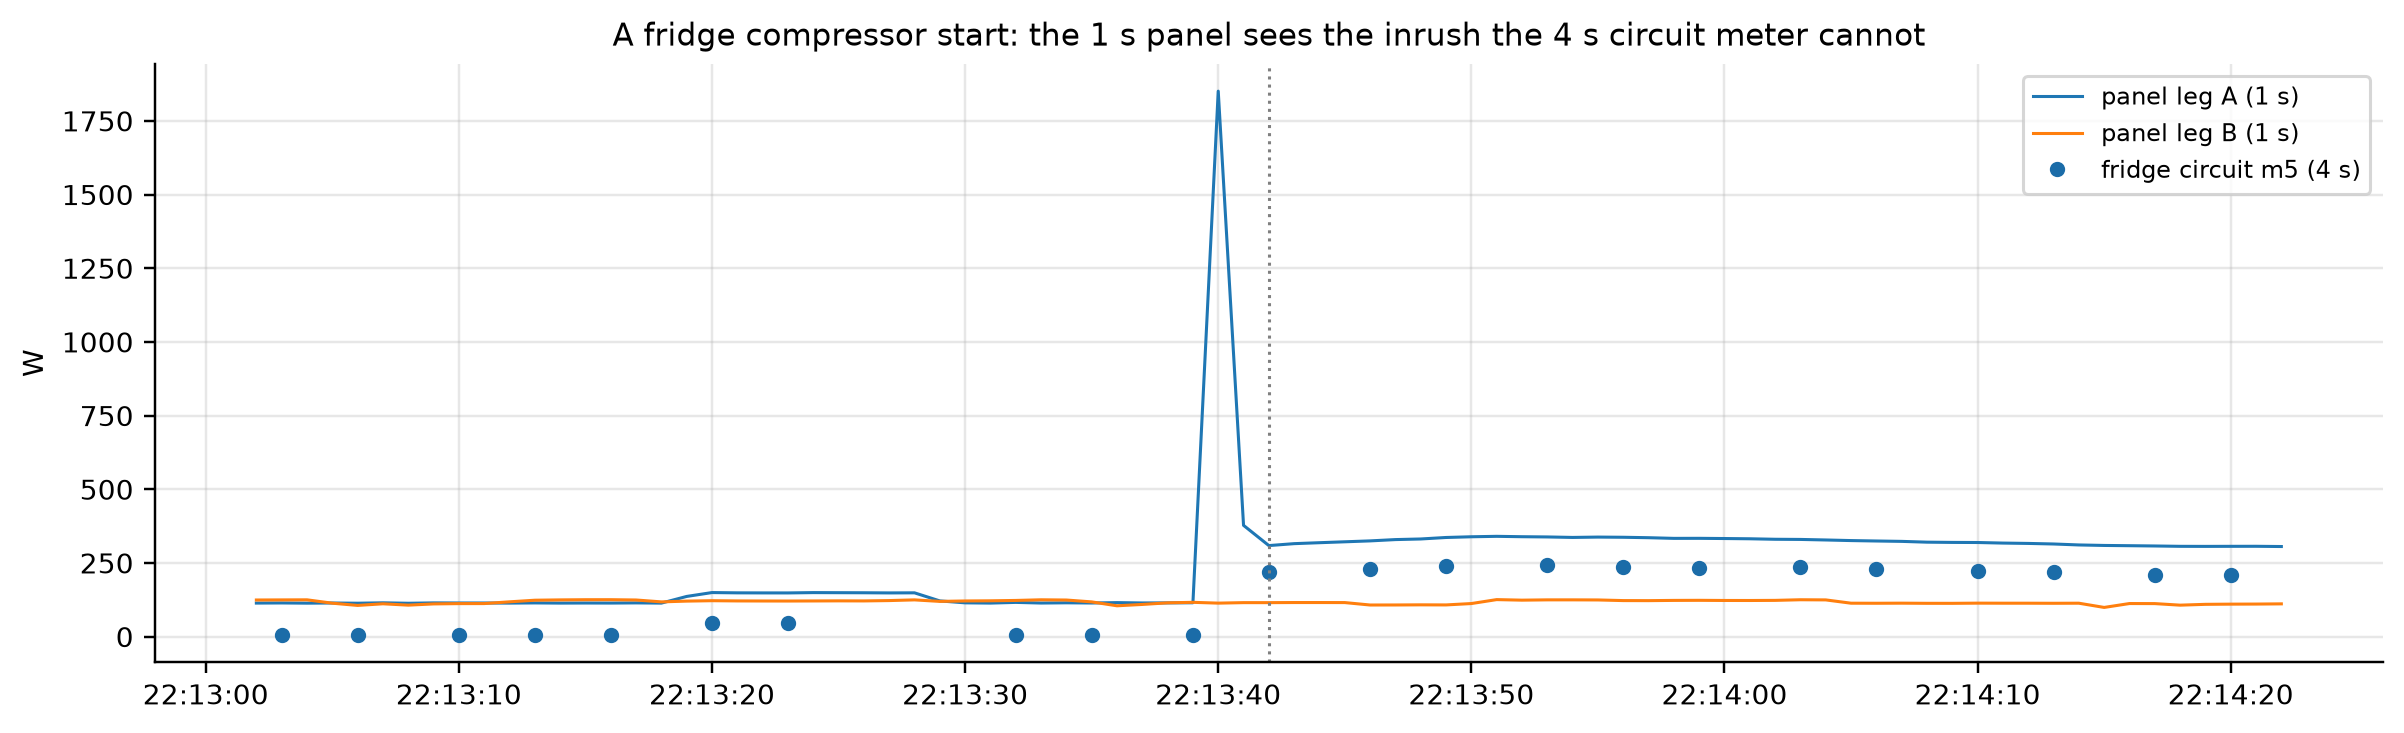

In [ ]:
_fr_ts, _fr_v = ch_store[5][0], ch_store[5][1]
_cand = np.where(fin & (np.abs(setA - 250) < 150) & (spikeA >= 1200))[0]
_i0 = int(_cand[len(_cand) // 2])
_t0 = int(ots[_i0])
_win = 40_000_000
_mm = (m1_ts >= _t0 - _win) & (m1_ts <= _t0 + _win)
_tt = pd.to_datetime(m1_ts[_mm], unit="us", utc=True)
_fig, _ax = plt.subplots(figsize=(11, 3.4))
_ax.plot(_tt, m1_v[_mm], lw=1.0, color="#1f77b4", label="panel leg A (1 s)")
_ax.plot(_tt, m2_v[_mm], lw=1.0, color="#ff7f0e", label="panel leg B (1 s)")
_fm = (_fr_ts >= _t0 - _win) & (_fr_ts <= _t0 + _win)
_ax.plot(pd.to_datetime(_fr_ts[_fm], unit="us", utc=True), _fr_v[_fm], "o", ms=4,
         color=eda.canon_color("fridge"), label="fridge circuit m5 (4 s)")
_ax.axvline(pd.Timestamp(_t0, unit="us", tz="UTC"), color="grey", ls=":", lw=1)
_ax.set_ylabel("W")
_ax.legend(loc="upper right", fontsize=8)
_ax.set_title("A fridge compressor start: the 1 s panel sees the inrush the 4 s circuit meter cannot")
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** The circuit meter tells a one-point story: 7 W, 7 W, **265 W** — the
compressor started, add 250 W. The panel tells the fuller one: leg A spikes to
**~1.5-1.9 kW for a single second** — the compressor's locked-rotor inrush — then
settles onto its +223 W plateau (median) — the draw the 4 s circuit finally catches.
Across all compressor-scale starts, the median one-sample inrush is **~1.4 kW, about six times
the running draw**, and the great majority of starts show a spike at least 3x the
settled step. Leg B does not move at all: the fridge sits on leg A. This is a
**submeter-invisible event class** — event detection on the aggregate catches motor
starts that no submeter ever recorded. [insight only] It is the mirror image of 01's
kettle finding: there, 6 s channels *missed* the kettle's 2.3 kW switch-on step; here,
the 1 s panel *sees* an inrush its own 4 s circuit meter misses. A disaggregator trained
only on submeter labels never learns to name these transients — and the aggregate
literally cannot be explained by the submeter record alone.

### 240 V loads step both legs

Raise the bar: keep only panel sample-pairs where **both** legs move by at least 150 W
in the same direction within the same second. A 120 V load cannot do that — only a
240 V element draws across both legs. This is a free 240 V appliance detector computed
from two numbers.

In [ ]:
_dsec = np.diff(m1_ts) / 1e6
pair = (_dsec > 0) & (_dsec <= 8.0)
dv1 = np.diff(m1_v)
dv2 = np.diff(m2_v)
jr = pair & (dv1 >= 150) & (dv2 >= 150)
jf = pair & (dv1 <= -150) & (dv2 <= -150)
anti = pair & (((dv1 >= 150) & (dv2 <= -150)) | ((dv1 <= -150) & (dv2 >= 150)))
jr_ts = m1_ts[1:][jr]
print("present consecutive panel sample-pairs: %s" % eda.fmt_int(int(pair.sum())))
print("both legs rise >= 150 W together (240 V ON events): %d" % int(jr.sum()))
print("both legs fall together (240 V OFF events): %d" % int(jf.sum()))
print("one leg up while the other down (counter-phase, >= 150 W): %d" % int(anti.sum()))
print("median co-step at rises: leg A %+.0f W, leg B %+.0f W" % (float(np.median(dv1[jr])), float(np.median(dv2[jr]))))

present consecutive panel sample-pairs: 1,561,631
both legs rise >= 150 W together (240 V ON events): 247
both legs fall together (240 V OFF events): 263
one leg up while the other down (counter-phase, >= 150 W): 8
median co-step at rises: leg A +1545 W, leg B +1582 W


In [ ]:
_ov_ts, _ov_v = ch_store[4][0], ch_store[4][1]  # m4, the second oven
_dov = np.diff(_ov_ts) / 1e6
_ook = (_dov > 0) & (_dov <= 12.0)
_ots4 = _ov_ts[1:][_ook & (np.diff(_ov_v) >= 300)]
_jr_idx = np.where(jr)[0]
_matches = []
for _tt0 in _ots4:
    _j = np.where(np.abs(jr_ts - _tt0) <= 4_000_000)[0]
    if len(_j):
        _matches.append((int(_tt0), int(_jr_idx[_j[0]])))
_steps_tot = np.array([dv1[_k] + dv2[_k] for _, _k in _matches])
_order = np.argsort(_steps_tot)
_tt0, _k = _matches[int(_order[len(_order) // 2])]
_win = 90_000_000
_mm = (m1_ts >= _tt0 - _win) & (m1_ts <= _tt0 + _win)
_tt = pd.to_datetime(m1_ts[_mm], unit="us", utc=True)
_fig, _ax = plt.subplots(2, 1, figsize=(11, 4.8), sharex=True)
_ax[0].plot(_tt, m1_v[_mm], lw=1.0, color="#1f77b4", label="leg A (1 s)")
_ax[0].plot(_tt, m2_v[_mm], lw=1.0, color="#ff7f0e", label="leg B (1 s)")
_ax[0].set_ylabel("W")
_ax[0].legend(fontsize=8, loc="upper left")
_ax[0].set_title("An oven element switching ON: both legs step together — the 240 V signature")
_m2m = (_ov_ts >= _tt0 - _win) & (_ov_ts <= _tt0 + _win)
_ax[1].plot(pd.to_datetime(_ov_ts[_m2m], unit="us", utc=True), _ov_v[_m2m], lw=1.2, marker="o", ms=2.5,
            color=eda.canon_color("electric oven"))
_ax[1].set_ylabel("W (circuit m4)")
_fig.tight_layout()
_fig  # render figure as cell output
print("median matched oven onset: total co-step leg A %+.0f W + leg B %+.0f W" % (float(dv1[_k]), float(dv2[_k])))

median matched oven onset: total co-step leg A +1187 W + leg B +1765 W


### Does the detector know its appliances?

Validation: take every labelled-circuit ON event (circuit rise >= 150 W), check whether
the panel was even *present* within a minute of it, and ask whether a joint rise
occurred within 4 s. An honest detector recovers the 240 V circuits whenever the panel
watched — and refuses to fire on 120 V loads.

In [ ]:
panel_min = np.unique(m1_ts // 60_000_000)
_rows = []
for _m in (3, 4, 10, 13, 14, 20):
    _info = amap["redd"]["building_1"]["meters"][str(_m)]
    _t, _v = ch_store[int(_m)][0], ch_store[int(_m)][1]
    _d = np.diff(_t) / 1e6
    _ok = (_d > 0) & (_d <= 12.0)
    _idx = np.where(_ok & (np.diff(_v) >= 150))[0]
    _otsm = _t[1:][_idx]
    if not len(_otsm):
        continue
    _inpan = np.isin(_otsm // 60_000_000, panel_min)
    _hit = np.array([np.any(np.abs(jr_ts - tt0) <= 4_000_000) for tt0 in _otsm])
    _rows.append(["m%s" % _m, _info["label"], str(len(_otsm)), str(int(_inpan.sum())), str(int(_hit.sum())),
                 ("%.0f%%" % (100 * float(_hit[_inpan].mean()))) if _inpan.any() else "never visible"])
mo.md(eda.md_table(["meter", "label", "ON events (circuit)", "panel-visible", "recovered", "recovery | panel-visible"], _rows))

| meter | label | ON events (circuit) | panel-visible | recovered | recovery \| panel-visible |
| --- | --- | --- | --- | --- | --- |
| m3 | electric oven | 54 | 28 | 27 | 96% |
| m4 | electric oven | 53 | 29 | 28 | 97% |
| m10 | washer dryer | 775 | 391 | 6 | 2% |
| m13 | electric space heater | 2 | 1 | 0 | 0% |
| m14 | electric stove | 61 | 0 | 0 | never visible |
| m20 | washer dryer | 271 | 122 | 115 | 94% |

**Reading it.** The detector is honest. The two ovens' element onsets are recovered
**96% and 97%** of the time the panel was watching; the 2.9 kW washer-dryer element
(m20) **94%** — those three meters are the home's 240 V loads, and the joint detector
rediscovers them from
the panel alone, no labels involved. The washer's 120 V motor triggers it 2% of the
time and the 174 W space heater never — correct rejections. And the star exhibit:
**the stove (m14) has 61 ON events >= 150 W and not one fell in a panel-covered minute.**
In building 1, every recorded stove event happened while the panel recorder was dark —
the aggregate record of this house contains no stove signature at all. [collectable]
The joint-rise test is cheap enough to run at ingest: store its event list as metadata
(like the leg assignments below), because it is the only appliance-level information
the panel gives for free. [insight only] 247 rises vs 263 falls is consistent to ~6%
(every ON has an OFF; elements cycle), and only 8-9 counter-phase steps appear in the
whole span — the legs genuinely move together for big loads, not in opposition.

### Which leg is the kitchen on?

For every labelled circuit with ON events, ask which panel leg moves at the event:
take the largest within-6 s rise on each leg and the settled step (median 3-20 s after
minus before). A circuit sits on the leg whose response is at least 3x the other's;
both legs moving means 240 V.

In [ ]:
_rows = []
for _m, _info in sorted(amap["redd"]["building_1"]["meters"].items(), key=lambda kv: int(kv[0])):
    _t, _v = ch_store[int(_m)][0], ch_store[int(_m)][1]
    _d = np.diff(_t) / 1e6
    _ok = (_d > 0) & (_d <= 12.0)
    _idx = np.where(_ok & (np.diff(_v) >= 60))[0]
    if len(_idx) < 3:
        _rows.append(["m%s" % _m, _info["label"], str(len(_idx)), "-", "-", "-", "-", "too few events"])
        continue
    _otsm = _t[1:][_idx]
    _cp = float(np.median(np.diff(_v)[_idx]))
    _rA, _sA = spike_and_settle(_otsm, m1_ts, m1_v)
    _rB, _sB = spike_and_settle(_otsm, m2_ts, m2_v)
    _finm = np.isfinite(_rA) & np.isfinite(_rB)
    if _finm.sum() == 0:
        _rows.append(["m%s" % _m, _info["label"], str(len(_otsm)), "%.0f" % _cp, "-", "-", "-", "never panel-visible"])
        continue
    _mA, _mB = float(np.median(_rA[_finm])), float(np.median(_rB[_finm]))
    _tA, _tB = float(np.median(_sA[_finm])), float(np.median(_sB[_finm]))
    if _mA >= 100 and _mB >= 100:
        _verdict = "240 V (both legs)"
    elif _mA >= 3 * max(_mB, 1) and _mA >= 50:
        _verdict = "leg A"
    elif _mB >= 3 * _mA and _mB >= 50:
        _verdict = "leg B"
    else:
        _verdict = "not resolvable"
    _rows.append(["m%s" % _m, _info["label"], "%d (%d vis)" % (len(_otsm), int(_finm.sum())), "%.0f" % _cp,
                 "%+.0f" % _mA, "%+.0f" % _mB, "%+.0f / %+.0f" % (_tA, _tB), _verdict])
mo.md(eda.md_table(["meter", "label", "ON events (vis)", "circuit dP p50 W", "leg A max rise p50", "leg B max rise p50", "settled A / B", "verdict"], _rows))

| meter | label | ON events (vis) | circuit dP p50 W | leg A max rise p50 | leg B max rise p50 | settled A / B | verdict |
| --- | --- | --- | --- | --- | --- | --- | --- |
| m3 | electric oven | 58 (29 vis) | 1650 | +1383 | +1550 | +1655 / +2458 | 240 V (both legs) |
| m4 | electric oven | 56 (30 vis) | 2464 | +1383 | +1587 | +1655 / +2458 | 240 V (both legs) |
| m5 | fridge | 672 (356 vis) | 218 | +1429 | +1 | +223 / -0 | leg A |
| m6 | dish washer | 404 (210 vis) | 228 | +2 | +302 | -0 / +223 | leg B |
| m7 | sockets | 2 | - | - | - | - | too few events |
| m8 | sockets | 8 (3 vis) | 64 | +5 | +72 | -1 / +60 | leg B |
| m9 | light | 98 (56 vis) | 93 | +93 | +1 | +94 / -0 | leg A |
| m10 | washer dryer | 2045 (1025 vis) | 127 | +4 | +12 | -0 / -2 | not resolvable |
| m11 | microwave | 806 (468 vis) | 1266 | +926 | +2 | +1448 / -1 | leg A |
| m12 | unknown | 56 (34 vis) | 1622 | +1225 | +1 | +1587 / -2 | leg A |
| m13 | electric space heater | 2 | - | - | - | - | too few events |
| m14 | electric stove | 64 | 1426 | - | - | - | never panel-visible |
| m15 | sockets | 76 (38 vis) | 1088 | +790 | +1 | +1050 / -1 | leg A |
| m16 | sockets | 65 (37 vis) | 1546 | +3 | +1179 | +1 / +1423 | leg B |
| m17 | light | 4 (1 vis) | 75 | +1 | +55 | -0 / +108 | leg B |
| m18 | light | 0 | - | - | - | - | too few events |
| m19 | unknown | 0 | - | - | - | - | too few events |
| m20 | washer dryer | 271 (121 vis) | 2948 | +2350 | +2249 | +2719 / +2465 | 240 V (both legs) |

**Reading it.** The building's wiring, reconstructed from physics. **Leg A hosts the
kitchen**: the fridge, the microwave (+926 W at its onsets), the kitchen sockets m15
(+790 W), and — the mystery of the label file — meter m12, an **"unknown" circuit that
draws 1.6 kW in 1,600-class steps 56 times over the span**. Someone in 2011 knew what
that was; the release did not say. Leg B hosts the dishwasher, the basement sockets m16
and light m17. The two ovens and the dryer element step **both** legs — the 240 V census
again. Three meters refuse to be pinned: the washer motor is too small for the panel's
resolution, the space heater fired only twice, and the **stove never cooked under a
watching panel**. [collectable] These leg assignments and the 240 V flags are durable
metadata — one hour of CT work in 2011, one JSON in gold forever. They also *explain*
the 30.8% leg imbalance: the fridge (the home's biggest single load), the microwave and
the mystery circuit all sit on leg A.

## Q3 — Two recorders, one house: who was watching, and when?

*Question: the panel covered 49.8% of its span; the circuits ~95% of theirs. How much
supervision survives when the two clocks are overlaid minute by minute — and how does
that overlap vary across the six buildings?*

REDD's two recorders have independent clocks and independent failure schedules. A
circuit label only teaches a pipeline something on minutes where **the panel was also
watching** — that overlap, not either record alone, is the supervised pool.

In [ ]:
dsec = np.diff(m1_ts) / 1e6
big = np.where(dsec > 3600)[0]
seg_start = np.concatenate([[m1_ts[0]], m1_ts[1:][big]])
seg_end = np.concatenate([m1_ts[:-1][big], [m1_ts[-1]]])
_rows = []
for _i in range(len(seg_start)):
    _rows.append(["island %d" % (_i + 1), str(pd.Timestamp(int(seg_start[_i]), unit="us", tz="UTC")),
                 str(pd.Timestamp(int(seg_end[_i]), unit="us", tz="UTC")),
                 "%.2f" % ((seg_end[_i] - seg_start[_i]) / 86400e6)])
    if _i < len(big):
        _rows.append(["  gap", str(pd.Timestamp(int(seg_end[_i]), unit="us", tz="UTC")),
                     str(pd.Timestamp(int(seg_start[_i + 1]), unit="us", tz="UTC")),
                     "%.2f" % (float(dsec[big[_i]]) / 86400.0)])
print("panel islands: %d | gaps > 1 h: %d | total dark: %.1f days of %.2f"
      % (len(seg_start), len(big), float(np.sum(dsec[dsec > 3600])) / 86400.0, (m1_ts[-1] - m1_ts[0]) / 86400e6))
mo.md(eda.md_table(["panel segment", "start (UTC)", "end (UTC)", "days"], _rows))

panel islands: 11 | gaps > 1 h: 10 | total dark: 18.0 days of 36.27


| panel segment | start (UTC) | end (UTC) | days |
| --- | --- | --- | --- |
| island 1 | 2011-04-18 13:22:09+00:00 | 2011-04-19 22:45:19+00:00 | 1.39 |
|   gap | 2011-04-19 22:45:19+00:00 | 2011-04-20 00:20:08+00:00 | 0.07 |
| island 2 | 2011-04-20 00:20:08+00:00 | 2011-04-21 07:17:09+00:00 | 1.29 |
|   gap | 2011-04-21 07:17:09+00:00 | 2011-04-21 10:17:17+00:00 | 0.13 |
| island 3 | 2011-04-21 10:17:17+00:00 | 2011-04-21 21:45:06+00:00 | 0.48 |
|   gap | 2011-04-21 21:45:06+00:00 | 2011-04-21 23:41:29+00:00 | 0.08 |
| island 4 | 2011-04-21 23:41:29+00:00 | 2011-04-28 09:57:47+00:00 | 6.43 |
|   gap | 2011-04-28 09:57:47+00:00 | 2011-04-30 03:10:34+00:00 | 1.72 |
| island 5 | 2011-04-30 03:10:34+00:00 | 2011-05-03 21:33:44+00:00 | 3.77 |
|   gap | 2011-05-03 21:33:44+00:00 | 2011-05-06 14:51:46+00:00 | 2.72 |
| island 6 | 2011-05-06 14:51:46+00:00 | 2011-05-07 15:59:16+00:00 | 1.05 |
|   gap | 2011-05-07 15:59:16+00:00 | 2011-05-11 07:19:43+00:00 | 3.64 |
| island 7 | 2011-05-11 07:19:43+00:00 | 2011-05-12 21:48:38+00:00 | 1.60 |
|   gap | 2011-05-12 21:48:38+00:00 | 2011-05-13 00:14:30+00:00 | 0.10 |
| island 8 | 2011-05-13 00:14:30+00:00 | 2011-05-13 09:16:24+00:00 | 0.38 |
|   gap | 2011-05-13 09:16:24+00:00 | 2011-05-22 20:04:46+00:00 | 9.45 |
| island 9 | 2011-05-22 20:04:46+00:00 | 2011-05-23 13:22:08+00:00 | 0.72 |
|   gap | 2011-05-23 13:22:08+00:00 | 2011-05-23 14:31:34+00:00 | 0.05 |
| island 10 | 2011-05-23 14:31:34+00:00 | 2011-05-24 18:32:05+00:00 | 1.17 |
|   gap | 2011-05-24 18:32:05+00:00 | 2011-05-24 19:55:33+00:00 | 0.06 |
| island 11 | 2011-05-24 19:55:33+00:00 | 2011-05-24 19:57:02+00:00 | 0.00 |

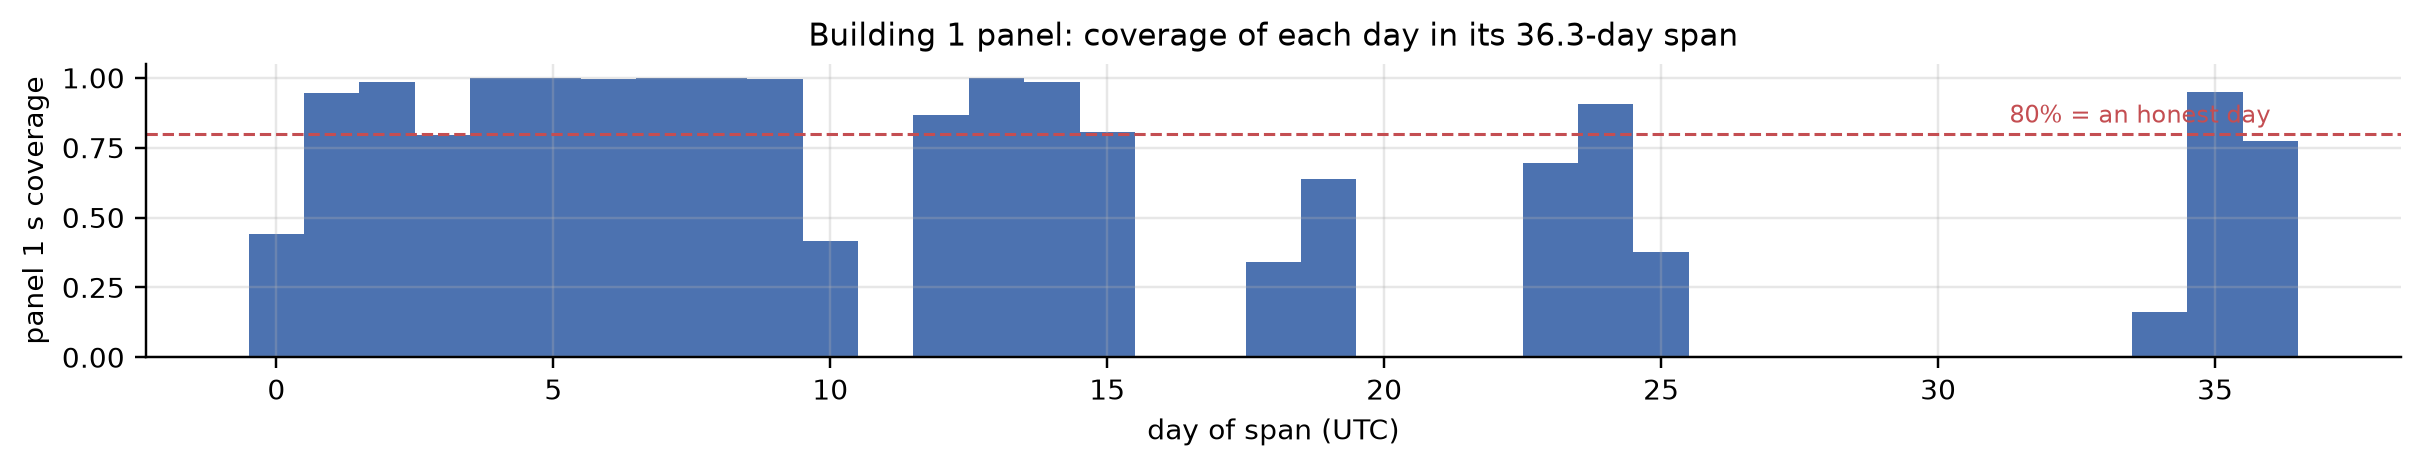

In [ ]:
day0 = int(m1_ts[0] // 86_400_000_000)
didx = (m1_ts // 86_400_000_000 - day0).astype(np.int64)
ndays = int(m1_ts[-1] // 86_400_000_000 - day0) + 1
cnt = np.bincount(didx, minlength=ndays) / 86400.0
_fig, _ax = plt.subplots(figsize=(11, 2.2))
_ax.bar(np.arange(ndays), cnt, color="#4c72b0", width=1.0)
_ax.axhline(0.8, color="#c44e52", ls="--", lw=1)
_ax.text(ndays - 1, 0.84, "80% = an honest day", ha="right", fontsize=8, color="#c44e52")
_ax.set_xlabel("day of span (UTC)")
_ax.set_ylabel("panel 1 s coverage")
_ax.set_title("Building 1 panel: coverage of each day in its 36.3-day span")
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** The panel's 36.3-day span is really **five day-scale islands of
watchful 1 s recording** (eleven if you count every blackout over an hour), separated
most of all by gaps of 1.72, 2.72, 3.64 and **9.45 days** — and the
day-by-day bars show how few days are actually *complete*: only **14 of 37** calendar
days reach the 80% coverage we call an honest day downstream. The recorder did not
degrade gracefully; it worked, then vanished, then worked. Any per-day statistic (daily
kWh, diurnal curves, day-matched attribution) is conditional on this mask, and Q8 shows
exactly how much that conditioning matters.

In [ ]:
grids = [ch_store[int(m)][0] for m in sorted(labels_b1, key=int)]
same = all(bool(np.array_equal(grids[0], g)) for g in grids[1:])
dts = np.diff(grids[0]) / 1e6
_dt_med = float(np.median(dts))
_span_d = (grids[0][-1] - grids[0][0]) / 86400e6
own_cov = 100 * len(grids[0]) / max((grids[0][-1] - grids[0][0]) / 1e6 / _dt_med, 1e-9)
mins_cov = 100 * len(np.unique(grids[0] // 60_000_000)) / max((grids[0][-1] - grids[0][0]) / 60e6 + 1, 1e-9)
print("all 18 b1 circuit meters share one exact timestamp grid:", same)
print("shared grid: %s rows | median dt %.1f s | span %.1f days | %.1f%% of own-cadence slots present | %.1f%% of minutes hold a sample"
      % (eda.fmt_int(len(grids[0])), _dt_med, _span_d, own_cov, mins_cov))

all 18 b1 circuit meters share one exact timestamp grid: True
shared grid: 745,878 rows | median dt 4.0 s | span 36.3 days | 95.2% of own-cadence slots present | 91.5% of minutes hold a sample


### The overlap is the supervised pool

Overlay the two clocks minute by minute: every minute with a circuit sample is a minute
of circuit supervision; only those where **the panel also has samples** can teach
mains-to-appliance mapping.

In [ ]:
circ_min = np.unique(grids[0] // 60_000_000)
_t_lo = int(min(int(m1_ts[0]), int(grids[0][0])) // 60_000_000)
_t_hi = int(max(int(m1_ts[-1]), int(grids[0][-1])) // 60_000_000)
n_all = _t_hi - _t_lo + 1
n_panel, n_circ = len(panel_min), len(circ_min)
n_both = int(len(np.intersect1d(panel_min, circ_min)))
n_ponly, n_conly = n_panel - n_both, n_circ - n_both
print("minute grid from first to last sample: %s minutes" % "{:,}".format(n_all))
print("panel present:    %6d min (%.1f%%)" % (n_panel, 100 * n_panel / n_all))
print("circuits present: %6d min (%.1f%%)" % (n_circ, 100 * n_circ / n_all))
print("both present:     %6d min (%.1f%%)  <- the supervised pool" % (n_both, 100 * n_both / n_all))
print("panel-only: %d min | circuit-only: %s min (%.1f%%) <- labelled hours the panel never saw"
      % (n_ponly, "{:,}".format(n_conly), 100 * n_conly / n_all))

minute grid from first to last sample: 52,236 minutes
panel present:     26300 min (50.3%)
circuits present:  47791 min (91.5%)
both present:      26298 min (50.3%)  <- the supervised pool
panel-only: 2 min | circuit-only: 21,493 min (41.1%) <- labelled hours the panel never saw


**Reading it.** The circuit recorder barely blinked: all 18 meters sit on **one exact
shared grid** of 745,878 rows — 95.2% of its own 4 s slots, 91.5% of minutes — with no
multi-day outage anywhere. The panel is the opposite: 49.8%. Put together, the honest
answer is brutal: of ~52,000 minutes, **26,298 (50.3%) have both recorders, and only
TWO minutes have the panel without the circuits** — the panel's dark time is a strict
superset of the circuit recorder's dark time. So 41% of the circuit record — thousands
of labelled appliance-hours — sits where the panel can never learn from it.
[collectable] The paired-coverage fraction (here 50.3%) is *the* supervision-density
metric for any two-recorder dataset: compute it at ingest, store it in gold, and gate
"ground truth" claims on it.

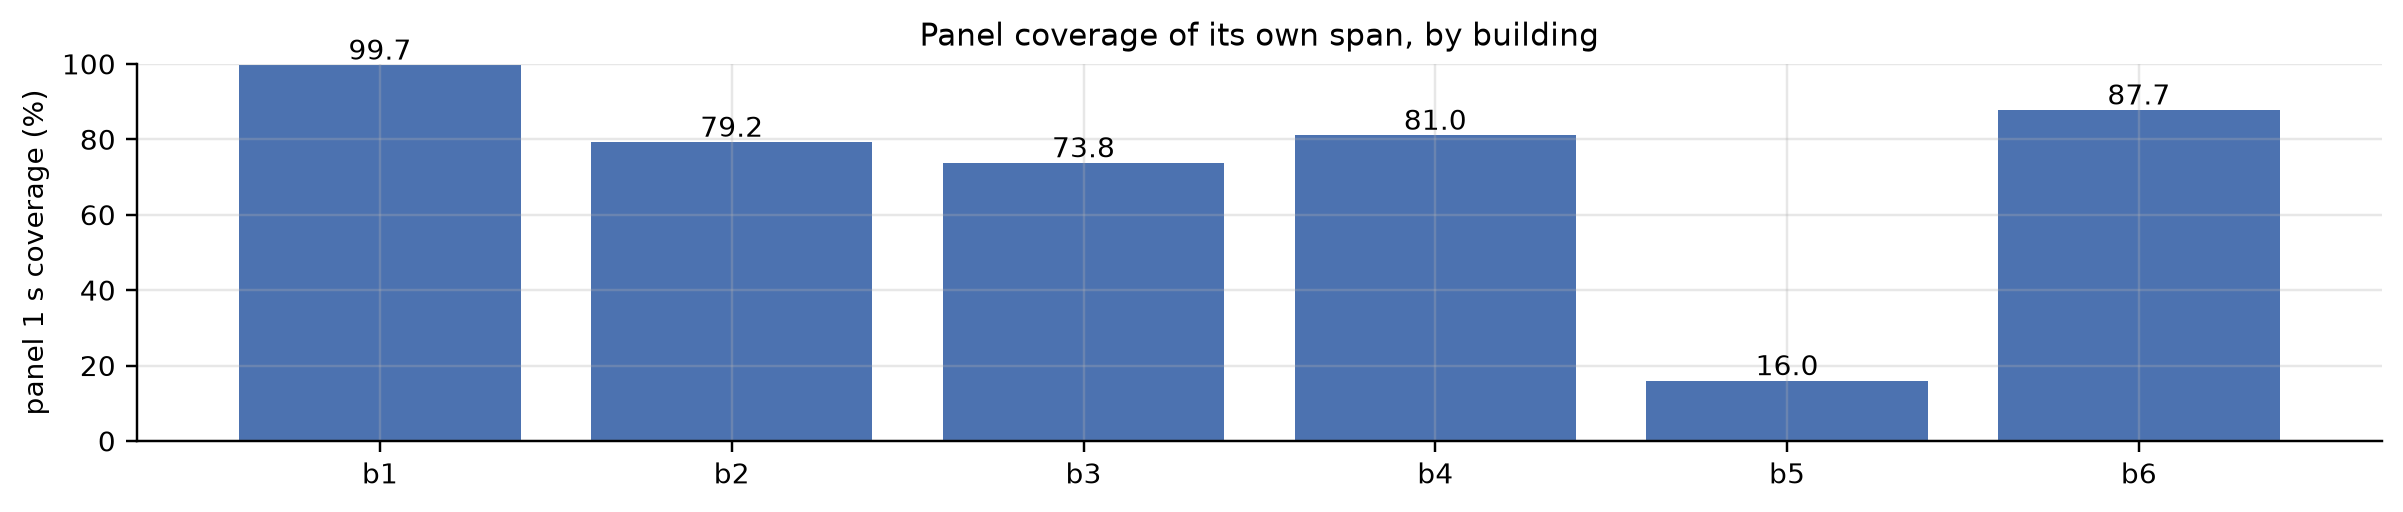

In [ ]:
_rows = []
_covs = []
for _b in range(1, 7):
    _ts_b = site_ts[_b]
    _span_d = (_ts_b[-1] - _ts_b[0]) / 86400e6
    _cov = 100 * len(_ts_b) / max((_ts_b[-1] - _ts_b[0]) / 1e6, 1e-9)
    _dts = np.diff(_ts_b) / 1e6
    _gaps = _dts[_dts > 3600]
    _max_gap_d = float(_gaps.max()) / 86400.0 if len(_gaps) else 0.0
    _day0 = int(_ts_b[0] // 86_400_000_000)
    _didx = (_ts_b // 86_400_000_000 - _day0).astype(np.int64)
    _ndays = int(_ts_b[-1] // 86_400_000_000 - _day0) + 1
    _cnt = np.bincount(_didx, minlength=_ndays)
    _n_full = int((_cnt >= 0.8 * 86400).sum())
    _rows.append(["b%d" % _b, "%.1f" % _span_d, "%.1f" % _cov, "%.2f" % _max_gap_d,
                 "%d / %d" % (_n_full, _ndays), len(amap["redd"]["building_%d" % _b]["meters"]), "%.1f" % cad_by_b[_b]])
    _covs.append(_cov)
mo.md(eda.md_table(["building", "span (d)", "panel 1 s cov %", "worst gap (d)", "honest days (>=80%)", "labelled circuits", "circuit dt (s)"], _rows))
_fig, _ax = plt.subplots(figsize=(11, 2.4))
_ax.bar(["b1", "b2", "b3", "b4", "b5", "b6"], _covs, color="#4c72b0")
for _i, _cv in enumerate(_covs):
    _ax.text(_i, _cv + 1.5, "%.1f" % _cv, ha="center", fontsize=9)
_ax.set_ylim(0, 100)
_ax.set_ylabel("panel 1 s coverage (%)")
_ax.set_title("Panel coverage of its own span, by building")
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** Six homes, six different experiments. b2/b3/b4/b6 hover around
**37-44%** panel coverage with worst gaps under 3 days; b1 gets to 49.8% but pays with
a 9.45-day hole; and **b5's panel covers just 8.0% of its 43.8-day span** — a 31.4-day
dark stretch, so b5 is effectively a circuits-only home. Honest days (>= 80%) range from
**14 of 37 (b1) down to zero in several buildings** — b6 assembles no complete panel day
at all, which quietly kills day-level attribution there (Q8). And the cadence column
repeats Q1's finding where it matters: half the homes logged circuits at 3 s, half at
4 s. [insight only] If REDD were the *only* corpus, you would be tempted to treat b5 as
broken and drop it; after 02's REFIT audit trail, the better reading is that every home
here is a partial instrument, and the metadata must say which parts worked.

### What the caches claim vs what the series says

REDD ships per-meter cache parquets — `good_sections` (recorder-reported intervals of
valid data) and `dropout_rate`. After 02's cache autopsy, trust but verify.

In [ ]:
import pyarrow.parquet as _pq

_gs = _pq.read_table(str(eda.fnd_file("redd", "building1_elec_cache_meter1_good_sections.parquet"))).to_pandas()
g_start = _gs["ts_us"].to_numpy().astype(np.int64)
g_end_raw = _gs["value_0"].to_numpy().astype(np.int64)
g_end = np.where(g_end_raw > 10**17, g_end_raw // 1000, g_end_raw)  # cache mixes us starts with ns ends
pairs = set(zip(g_start.tolist(), g_end.tolist()))
print("good_sections: %d rows, %d unique (start, end) pairs" % (len(_gs), len(pairs)))
print("claimed continuity: %.2f days (max end - min start)" % ((g_end.max() - g_start.min()) / 86400e6))
print("unit check: start col in MICROseconds; end values in NANOseconds (%d of %d above 1e17)" % (int((g_end_raw > 10**17).sum()), len(g_end_raw)))
_dr5 = _pq.read_table(str(eda.fnd_file("redd", "building1_elec_cache_meter5_dropout_rate.parquet"))).to_pandas()
print("dropout_rate b1 fridge (m5): value_0 = %.4f (%.1f%% missing)" % (float(_dr5["value_0"].iloc[0]), 100 * float(_dr5["value_0"].iloc[0])))

good_sections: 26 rows, 1 unique (start, end) pairs
claimed continuity: 36.27 days (max end - min start)
unit check: start col in MICROseconds; end values in NANOseconds (26 of 26 above 1e17)
dropout_rate b1 fridge (m5): value_0 = 0.2204 (22.0% missing)


**Reading it.** Two diseases, both familiar from 02. First, the units: `good_sections`
stores its starts in **microseconds and its ends in nanoseconds** in the same logical
column — anyone decoding naively gets end-times 1,000x in the future. Second, the
content: the cache reports **36.27 days of unbroken continuity in a single (start, end)
pair, repeated 26 times** — for a meter that actually covered **49.8%** of its span in
eleven islands. The recorder's self-reported health summary simply does not describe the
series it shipped with. The dropout cache is subtler: it says **22.0%** missing for the
fridge meter, which is *true against a 1 Hz yardstick* (a 4 s channel cannot fill 1 Hz
slots) but wildly misleading against the channel's own 4 s cadence, where only **4.8%**
of slots are missing. [collectable] Store the good-sections *decode rule* (us starts,
ns-or-us ends) next to the gold layer — anyone re-deriving coverage from caches without
it will reconstruct a dataset that never existed.

In [ ]:
# workhorse for the rest of the notebook: every labelled circuit in all six buildings
ch_all = {}
inv_rows = []
for _b in range(1, 7):
    for _m, _info in sorted(amap["redd"]["building_%d" % _b]["meters"].items(), key=lambda kv: int(kv[0])):
        _ts, _v = eda.read_channel(eda.fnd_file("redd", "building%d_elec_meter%s.parquet" % (_b, _m)), "value_0")
        ch_all[(_b, int(_m))] = (_ts, _v)
        _kwh = eda.kwh_of(_ts, _v, missing_values=(), dt_cap_s=30.0)
        _dts = np.diff(_ts) / 1e6
        _dts = _dts[(_dts > 0) & (_dts <= 60)]
        inv_rows.append([_b, int(_m), _info["label"], _info.get("canonical") or "", round(float(_kwh), 2),
                         round(float(np.median(_dts)) if len(_dts) else np.nan, 1)])
inv = pd.DataFrame(inv_rows, columns=["b", "meter", "label", "canonical", "kwh_cap30", "dt_med_s"])
print("loaded %d labelled circuits across 6 buildings" % len(ch_all))

loaded 104 labelled circuits across 6 buildings


## Q4 — The label matrix: what REDD says it labelled, and how much of that is real

*Question: 104 circuits carry human labels — how do they map onto our five canonical
appliances, and how many of them never recorded anything worth the disk they sit on?*

In [ ]:
rows_b1 = [["m%d" % int(r.meter), r.label, r.canonical or "-", "%.2f" % r.kwh_cap30, "%.1f" % r.dt_med_s]
           for r in cdf.itertuples()]
mo.md(eda.md_table(["meter", "label", "canonical", "kWh over span (cap 30 s)", "median dt (s)"], rows_b1))

| meter | label | canonical | kWh over span (cap 30 s) | median dt (s) |
| --- | --- | --- | --- | --- |
| m3 | electric oven | nan | 3.81 | 4.0 |
| m4 | electric oven | nan | 5.01 | 4.0 |
| m5 | fridge | fridge | 44.74 | 4.0 |
| m6 | dish washer | dishwasher | 19.92 | 4.0 |
| m7 | sockets | nan | 16.78 | 4.0 |
| m8 | sockets | nan | 22.94 | 4.0 |
| m9 | light | nan | 30.73 | 4.0 |
| m10 | washer dryer | washing_machine | 3.45 | 4.0 |
| m11 | microwave | microwave | 16.89 | 4.0 |
| m12 | unknown | nan | 5.22 | 4.0 |
| m13 | electric space heater | nan | 0.10 | 4.0 |
| m14 | electric stove | nan | 0.41 | 4.0 |
| m15 | sockets | nan | 4.51 | 4.0 |
| m16 | sockets | nan | 2.26 | 4.0 |
| m17 | light | nan | 18.29 | 4.0 |
| m18 | light | nan | 11.81 | 4.0 |
| m19 | unknown | nan | 0.00 | 4.0 |
| m20 | washer dryer | washing_machine | 29.16 | 4.0 |

In [ ]:
tally = inv[inv["canonical"] != ""].groupby(["b", "canonical"]).size().unstack(fill_value=0)
tally = tally.reindex(columns=["fridge", "dishwasher", "washing_machine", "microwave"], fill_value=0)
rows_t = [["b%d" % int(bb)] + [str(int(tally.loc[bb, cc])) for cc in tally.columns] for bb in tally.index]
mo.md(eda.md_table(["building", "fridge", "dishwasher", "washing machine", "microwave"], rows_t))

| building | fridge | dishwasher | washing machine | microwave |
| --- | --- | --- | --- | --- |
| b1 | 1 | 1 | 2 | 1 |
| b2 | 1 | 1 | 1 | 1 |
| b3 | 1 | 1 | 2 | 1 |
| b4 | 0 | 1 | 1 | 0 |
| b5 | 1 | 1 | 2 | 1 |
| b6 | 1 | 1 | 1 | 0 |

**Reading it.** REDD's 104 labelled circuits carry **24 canonical tags**: 5 fridge
(b1, b2, b3, b5, b6), 6 dishwashers, 9 washer/dryer meters, 4 microwaves. Building 4
labels **no fridge at all** — the one home without the appliance every other home has.
The rest is period-specific and charming: *waste disposal units* (three homes), *smoke
alarms*, *air conditioners* and an *electric furnace* (US heating, not the UK boiler
shoulder of 01), two `CE appliance` catch-alls, b5's two `subpanel` meters, and
**eight `unknown` circuits** — including b1's mystery m12 (1.6 kW steps, Q2). And the
headline absence, already flagged in Q1: **no kettle exists anywhere in REDD** — the
2011-US cooking story is ovens, stoves and microwaves, so the appliance that dominates
UK demand in 01 is simply absent here.

In [ ]:
dead = inv[inv["kwh_cap30"] < 0.5].sort_values("kwh_cap30")
tbl = [[("b%d m%d" % (int(r.b), int(r.meter))), r.label, "%.3f" % r.kwh_cap30] for r in dead.itertuples()]
print("dead meters (< 0.5 kWh over the whole span): %d of %d" % (len(dead), len(inv)))
mo.md(eda.md_table(["meter", "label", "kWh over whole span (cap 30 s)"], tbl))

dead meters (< 0.5 kWh over the whole span): 29 of 104


| meter | label | kWh over whole span (cap 30 s) |
| --- | --- | --- |
| b1 m19 | unknown | 0.000 |
| b5 m15 | sockets | 0.000 |
| b5 m21 | waste disposal unit | 0.000 |
| b5 m26 | sockets | 0.000 |
| b5 m9 | washer dryer | 0.000 |
| b4 m20 | air conditioner | 0.000 |
| b5 m4 | light | 0.000 |
| b4 m12 | smoke alarm | 0.020 |
| b5 m7 | sockets | 0.020 |
| b5 m8 | washer dryer | 0.020 |
| b4 m10 | air conditioner | 0.030 |
| b2 m11 | waste disposal unit | 0.030 |
| b3 m4 | sockets | 0.040 |
| b3 m8 | waste disposal unit | 0.040 |
| b5 m25 | sockets | 0.040 |
| b5 m17 | light | 0.050 |
| b4 m9 | air conditioner | 0.070 |
| b3 m15 | light | 0.080 |
| b6 m9 | dish washer | 0.080 |
| b1 m13 | electric space heater | 0.100 |
| b5 m14 | light | 0.270 |
| b5 m16 | unknown | 0.300 |
| b4 m16 | unknown | 0.330 |
| b3 m5 | light | 0.340 |
| b4 m6 | sockets | 0.350 |
| b4 m17 | unknown | 0.350 |
| b3 m18 | smoke alarm | 0.400 |
| b1 m14 | electric stove | 0.410 |
| b2 m5 | electric stove | 0.480 |

**Reading it.** **29 of 104 labelled circuits — 28% — never drew 0.5 kWh in their
entire recording window.** The casualties are not exotic: among them are b5's **two
"washer dryer" meters (m8: 0.02 kWh, m9: 0.00 kWh)** that essentially never ran, and
b6's **dishwasher (m9: 0.078 kWh)** — a labelled appliance with no measurable career.
Smoke alarms and one-sample blips explain some; sub-1 W idle draw explains the rest;
a few are simply appliances the occupants never used during the sprint. The lesson
transfers directly to our Shelly deployment: a labelled channel is an *offer* of
supervision, not a guarantee — every label file needs an energy-based liveness check
before it enters training. [collectable] Add a `dead` flag (threshold: < 0.5 kWh per
recorded month) to the gold appliance map — it costs nothing and would have saved 02
and 04 a round of confusion.

## Q5 — The 5 W floor: when the ON-rule meets always-on loads

*Question: the half-median ON threshold fires below 5 W on low-draw circuits — what
does that do to duty cycles and episodes, and does the floor-repaired rule recover
them?*

The gold threshold rule sets a channel's ON threshold at half its median draw. For
circuits whose median sits at a few watts — sockets with idle electronics, smoke
alarms, the fridge between compressor runs — that threshold lands under the project's
5 W floor, and the legacy variant happily declares a 100%-duty appliance.

In [ ]:
duty_rows = []
degenerate = []
_worst = None
for (_b, _m), (_ts, _v) in sorted(ch_all.items()):
    _info = amap["redd"]["building_%d" % _b]["meters"][str(_m)]
    _sl = eda.channel_stats(_ts, _v, missing_values=(), thr_rule="legacy")
    _sf = eda.channel_stats(_ts, _v, missing_values=(), thr_rule="floor")
    _row = [_b, _m, _info["label"], round(float(_sl["thr_on_w"]), 1), round(100 * float(_sl["on_share"]), 1),
           round(float(_sf["thr_on_w"]), 1), round(100 * float(_sf["on_share"]), 1),
           round(float(_sf["episodes_per_day"]), 1)]
    duty_rows.append(_row)
    if float(_sl["on_share"]) >= 0.999:
        degenerate.append(_row)
    if _b == 1:
        _dw = _sl["dwell_array"]
        if len(_dw) and (_worst is None or _dw.max() > _worst[1]):
            _worst = (_m, float(_dw.max()))
print("channels with legacy duty = 100%%: %d of %d" % (len(degenerate), len(duty_rows)))
print("longest legacy ON episode in b1: m%d -> %.0f s = %.1f days" % (_worst[0], _worst[1], _worst[1] / 86400))
for (_b, _m) in [(1, 6), (1, 5)]:
    _v = ch_all[(_b, _m)][1]
    _p50 = float(np.percentile(_v, 50))
    print("b%d m%d: p50 = %.0f W -> half-median rule: %.1f W ON threshold" % (_b, _m, _p50, _p50 / 2))

channels with legacy duty = 100%: 5 of 104
longest legacy ON episode in b1: m7 -> 2983512 s = 34.5 days
b1 m6: p50 = 0 W -> half-median rule: 0.0 W ON threshold
b1 m5: p50 = 7 W -> half-median rule: 3.5 W ON threshold


In [ ]:
mo.md(eda.md_table(["b", "m", "label", "thr legacy W", "duty legacy %", "thr floor W", "duty floor %", "episodes/day floor"],
                   [[str(x) for x in r] for r in degenerate]))

| b | m | label | thr legacy W | duty legacy % | thr floor W | duty floor % | episodes/day floor |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | 7 | sockets | 10.5 | 100.0 | 24.0 | 3.8 | 480.2 |
| 1 | 8 | sockets | 11.0 | 100.0 | 35.5 | 17.3 | 12.8 |
| 4 | 13 | light | 12.5 | 100.0 | 23.5 | 74.1 | 65.1 |
| 5 | 10 | subpanel | 6.2 | 100.0 | 116.2 | 5.4 | 0.2 |
| 5 | 23 | light | 35.0 | 100.0 | 180.0 | 13.5 | 0.2 |

**Reading it.** **5 of 104 channels are degenerate under the legacy rule** — a 100%
duty cycle, i.e. the threshold rule decided they were ON for the entire span. The floor
repair (never threshold below 5 W) restores sanity almost everywhere. Building 1's two
failures are the instructive pair: **m7 (sockets) drops from 100% to 3.8% duty** — it
was 34.5 days of one continuous "ON episode" under the legacy rule, a single event
longer than the recording span — and **m8 (sockets) from 100% to 17.3%**. Meanwhile the
fridge (m5) — whose half-median threshold is 3.5 W, below every idle plateau — goes
from a near-always-ON blob to **17.8 episodes/day with a median dwell of
~1,100 s (18 minutes)** — the compressor actually cycles about 18 times a day, and the
floor-repaired threshold is what lets an episode finder see that. The dishwasher's 197 W
threshold (half its 394 W median) is the healthy case the rule was designed for.
[insight only] This failure class is not a REDD quirk: every Shelly channel with an
idle draw — routers, chargers, always-on AV — will reproduce it, which is why the floor
rule lives in the shared threshold code, not in this notebook.

## Q6 — Day gallery: the loudest honest day and the ordinary one

*Question: what do an honest day's extremes and a median day actually look like at 1 s,
with the fridge cycling underneath?*

honest days (>=80% coverage): 14 | median honest-day energy 7.4 kWh
peak honest day: span day +12, 19.7 kWh | ordinary day: span day +7, 6.7 kWh


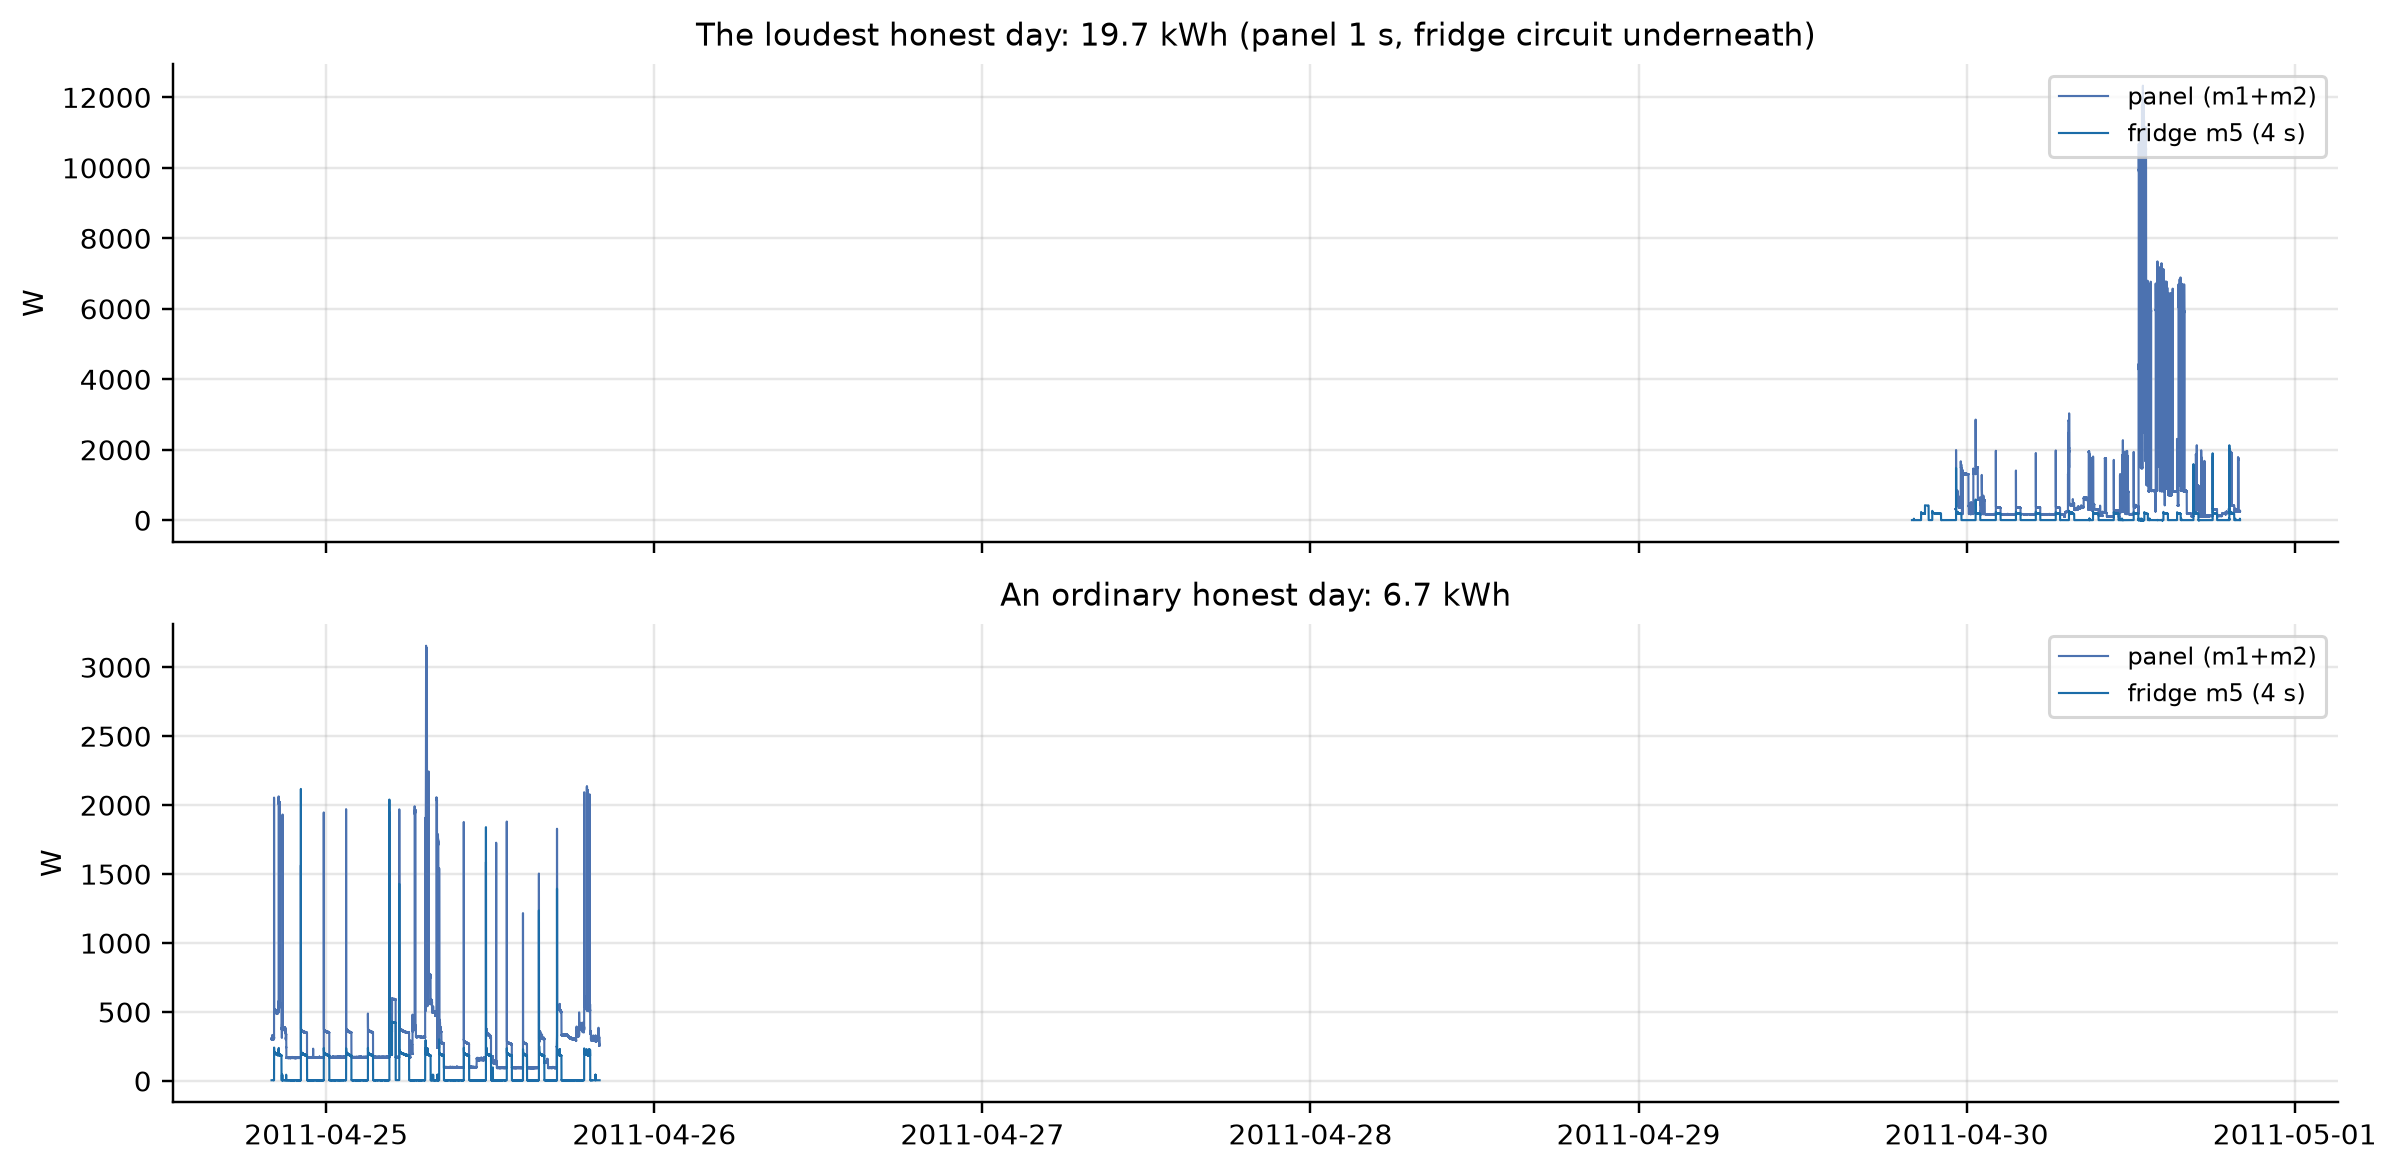

In [ ]:
_w = m1_v + m2_v
_dts = np.diff(m1_ts) / 1e6
_dE = np.where(_dts <= 10.0, _w[:-1] * _dts, 0.0)
_last_day = int(didx[-1])
day_E = np.bincount(didx[:-1], weights=_dE, minlength=_last_day + 1) / 3.6e6
_cnt_day = np.bincount(didx, minlength=_last_day + 1)
honest = np.where(_cnt_day >= 0.8 * 86400)[0]
med_E = float(np.median(day_E[honest]))
peak_day = int(honest[int(np.argmax(day_E[honest]))])
typ_day = int(honest[int(np.argmin(np.abs(day_E[honest] - med_E)))])
print("honest days (>=80%% coverage): %d | median honest-day energy %.1f kWh" % (len(honest), med_E))
print("peak honest day: span day +%d, %.1f kWh | ordinary day: span day +%d, %.1f kWh"
      % (peak_day, day_E[peak_day], typ_day, day_E[typ_day]))

def _day_plot(ax, day_idx, title):
    sel = didx == day_idx
    tloc = pd.to_datetime(m1_ts[sel], unit="us", utc=True).tz_convert("Etc/GMT+4")
    ax.plot(tloc, _w[sel], lw=0.7, color="#4c72b0", label="panel (m1+m2)")
    ft, fv = ch_all[(1, 5)]
    fsel = (ft // 86_400_000_000 - day0) == day_idx
    ax.plot(pd.to_datetime(ft[fsel], unit="us", utc=True).tz_convert("Etc/GMT+4"), fv[fsel],
            lw=0.7, color=eda.canon_color("fridge"), label="fridge m5 (4 s)")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_ylabel("W")

_fig, _ax = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True)
_day_plot(_ax[0], peak_day, "The loudest honest day: %.1f kWh (panel 1 s, fridge circuit underneath)" % day_E[peak_day])
_day_plot(_ax[1], typ_day, "An ordinary honest day: %.1f kWh" % day_E[typ_day])
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** The ordinary day is the story of this dataset in miniature: a fridge
sawtooth cycling all day (18 compressor runs, each visible as a clean +250 W plateau on
the circuit and a +1.5 kW spike on the panel), a modest midday bump, an evening cooking
shoulder after 17:00 local, and nothing above a couple of kilowatts. The loud day adds
the two things American houses do that UK ones barely attempt: **an electric dryer's
2.9 kW element cycling for hours** and a longer oven session — the panel spends the
afternoon pinned near its p95. Both days show the 1 s sampler earning its keep: without
it, the dryer's duty cycling and the fridge's inrush spikes would smear into an
unexplainable "base load". [collectable] Honest-day day-plots like these are the fastest
sanity check when a new submeter deployment lands: no statistics, just look at five
days.

## Q7 — Episode anatomy: one dishwasher run, dissected

*Question: what does a single appliance career look like at 4 s, and what do the
median episode statistics hide?*

b1 dishwasher m6 (floor rule): thr 197 W | duty 3.6% | episodes 336 (9.26/day)
dwell p10/p50/p90: 32 / 176 / 818 s
careers (ON runs bridged over OFF gaps <= 8 min): 18 over 36.3 days (0.5/day)
career energy kWh: p25 1.09 | median 1.17 | p75 1.22 | max 1.40


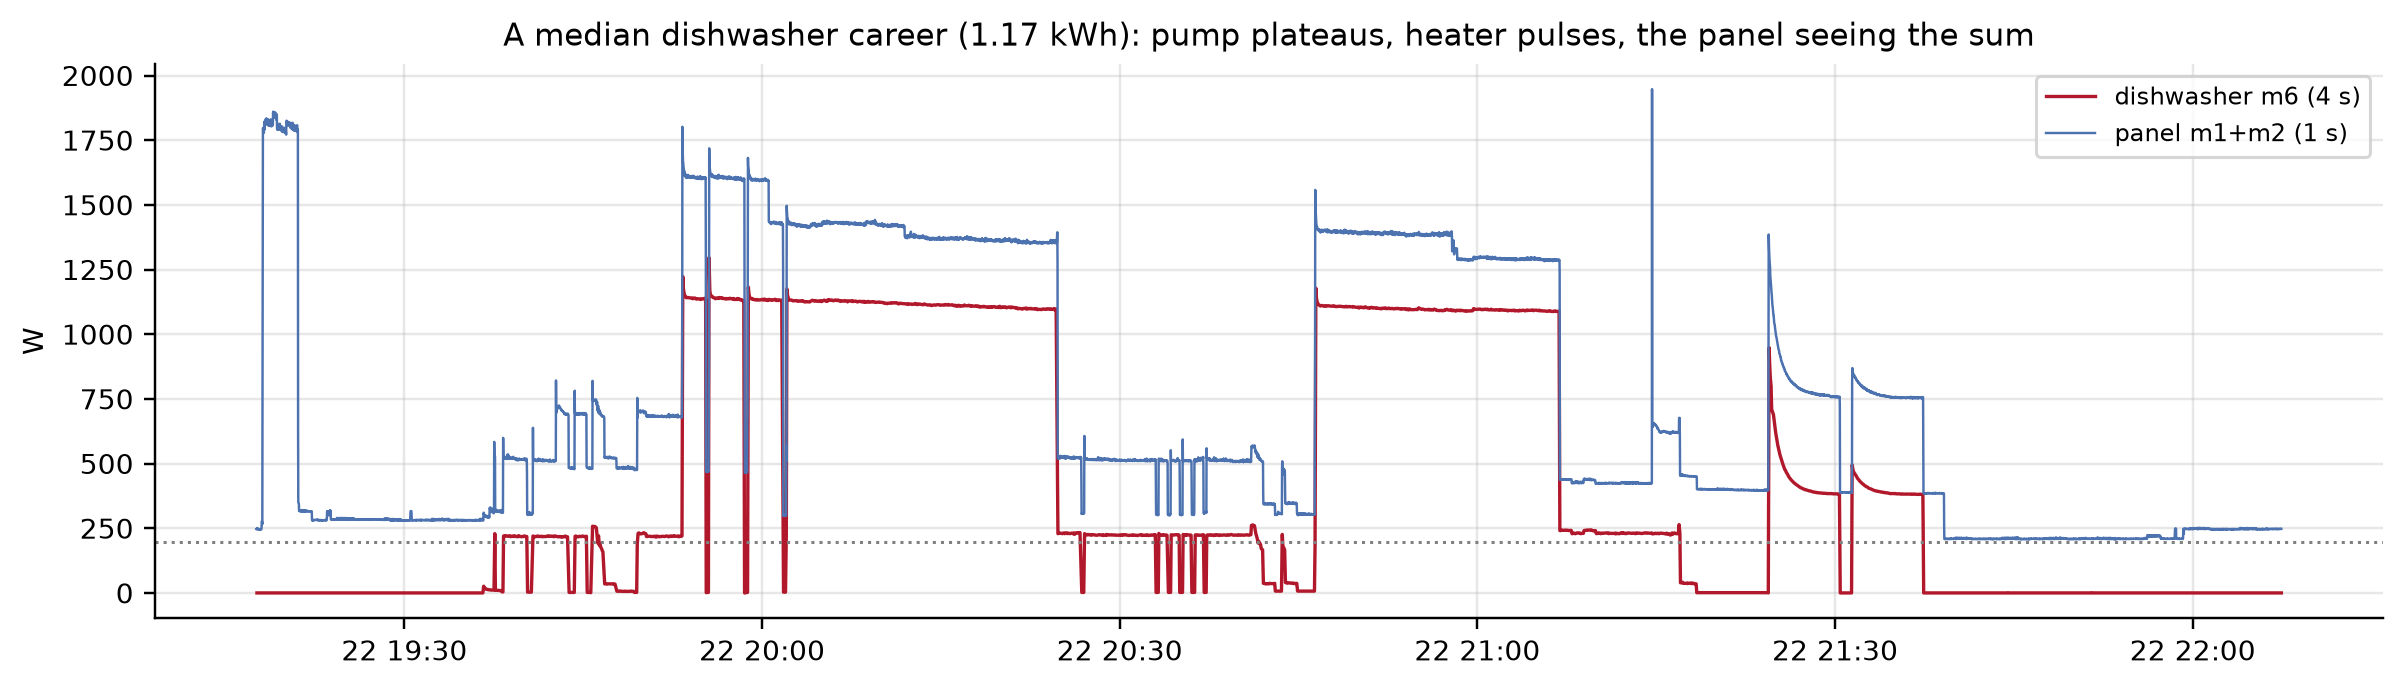

In [ ]:
_ts6, _v6 = ch_all[(1, 6)]
st6 = eda.channel_stats(_ts6, _v6, missing_values=(), thr_rule="floor")
thr6 = float(st6["thr_on_w"])
print("b1 dishwasher m6 (floor rule): thr %.0f W | duty %.1f%% | episodes %d (%.2f/day)" %
      (thr6, 100 * float(st6["on_share"]), st6["episodes"], float(st6["episodes_per_day"])))
print("dwell p10/p50/p90: %.0f / %.0f / %.0f s" % (st6["dwell_p10_s"], st6["dwell_p50_s"], st6["dwell_p90_s"]))
_on = _v6 > thr6
_d = np.diff(_on.astype(np.int8))
_r0 = np.where(_d == 1)[0] + 1
_r1 = np.where(_d == -1)[0] + 1
if bool(_on[0]):
    _r0 = np.r_[0, _r0]
if bool(_on[-1]):
    _r1 = np.r_[_r1, len(_on)]
_gapt = _ts6[_r0[1:]] - _ts6[_r1[:-1]]
_brid = _gapt <= 480_000_000  # a career's fill/soak pauses are minutes, not hours
_grp = np.concatenate([[0], np.cumsum(~_brid)])
_ncar = int(_grp[-1]) + 1
_first = np.searchsorted(_grp, np.arange(_ncar))
_last = np.searchsorted(_grp, np.arange(_ncar), side="right") - 1
_cs = _ts6[_r0[_first]]
_ce = _ts6[_r1[_last]]
_dts6 = np.diff(_ts6) / 1e6
_dE6 = np.where((_dts6 > 0) & (_dts6 <= 30.0), _v6[:-1] * _dts6, 0.0) / 3.6e6
eE = np.array([float(_dE6[(_ts6[:-1] >= _cs[_i]) & (_ts6[:-1] <= _ce[_i])].sum()) for _i in range(_ncar)])
_span6 = (_ts6[-1] - _ts6[0]) / 86400e6
print("careers (ON runs bridged over OFF gaps <= 8 min): %d over %.1f days (%.1f/day)" % (_ncar, _span6, _ncar / _span6))
print("career energy kWh: p25 %.2f | median %.2f | p75 %.2f | max %.2f" %
      (np.percentile(eE, 25), np.median(eE), np.percentile(eE, 75), float(eE.max())))
_i0 = int(np.argsort(eE)[len(eE) // 2])
_t0e = int(_cs[_i0]) - 20 * 60_000_000
_t1e = int(_ce[_i0]) + 30 * 60_000_000
_mm = (_ts6 >= _t0e) & (_ts6 <= _t1e)
_wm = (m1_ts >= _t0e) & (m1_ts <= _t1e)
_fig, _ax = plt.subplots(figsize=(11, 3.2))
_ax.plot(pd.to_datetime(_ts6[_mm], unit="us", utc=True).tz_convert("Etc/GMT+4"), _v6[_mm], lw=1.1,
         color=eda.canon_color("dishwasher"), label="dishwasher m6 (4 s)")
_ax.plot(pd.to_datetime(m1_ts[_wm], unit="us", utc=True).tz_convert("Etc/GMT+4"), (m1_v + m2_v)[_wm],
         lw=0.8, color="#4c72b0", label="panel m1+m2 (1 s)")
_ax.axhline(thr6, color="grey", ls=":", lw=1)
_ax.set_ylabel("W")
_ax.legend(fontsize=8, loc="upper right")
_ax.set_title("A median dishwasher career (%.2f kWh): pump plateaus, heater pulses, the panel seeing the sum" % eE[_i0])
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** The threshold's raw statistics are a mirage: **336 "episodes" over 36
days (9.3/day)** — but their median dwell is 176 s and the median
episode carries about **0.01 kWh — pump blips, not runs**. Bridging the OFF gaps a
career naturally contains (fill/soak pauses under 8 min) reconstructs **18 real
careers over the span — one every other day, 1.17 kWh median (p25-p75: 1.09-1.22,
max 1.40)**. The figure shows the median career: a **wash-pump plateau** near the
threshold (the part that defines "duty"), **heater pulses an order of magnitude above
it** (the part that dominates energy), and idle gaps while the cycle soaks. The panel
trace shows the same career as the house experiences it — its heater pulses are the
biggest steps in the hour, and everything else disappears into the fridge sawtooth.
This is why per-*career* energy beats per-episode *duration* as the disaggregation
label: duration is pump-controlled, energy is heater-controlled. [collectable] Any
per-run statistic computed on raw threshold episodes should state its bridging rule —
with none, REDD's "dishwasher runs 9 times a day". [insight only] Same structure as
02's REFIT washer: motor+heater duality — a useful prior for the Shelly campaign's
appliance profiles.

## Q8 — Attribution: how much of the house do the labels explain?

*Question: on the days when the panel actually watched, what fraction of whole-home
energy do the labelled circuits account for — and which homes can we even ask?*

Method: restrict to honest days (panel >= 80% coverage), integrate panel and labelled
circuits over exactly those days (10 s cap for panels, 30 s for circuits), and take the
ratio. Day-matching matters: over the raw span, outages silently dilute both sides.

In [ ]:
attr_rows = []
attr_pct = {}
for _b in range(1, 7):
    _site = amap["redd"]["building_%d" % _b]["site_meters"]
    _arrs = [eda.read_channel(eda.fnd_file("redd", "building%d_elec_meter%s.parquet" % (_b, sm)), "value_0")
            for sm in _site]
    if len(_arrs) == 2 and bool(np.array_equal(_arrs[0][0], _arrs[1][0])):
        _ts_b, _v_b = _arrs[0][0], _arrs[0][1] + _arrs[1][1]
    else:
        _ts_b, _v_b = eda.read_mains([
            (str(eda.fnd_file("redd", "building%d_elec_meter%s.parquet" % (_b, sm))), "value_0") for sm in _site])
    _day0_b = int(_ts_b[0] // 86_400_000_000)
    _didx_b = (_ts_b // 86_400_000_000 - _day0_b).astype(np.int64)
    _last_b = int(_didx_b[-1])
    _dts_b = np.diff(_ts_b) / 1e6
    _dE_b = np.where((_dts_b > 0) & (_dts_b <= 10.0), _v_b[:-1] * _dts_b, 0.0)
    _day_Eb = np.bincount(_didx_b[:-1], weights=_dE_b, minlength=_last_b + 1) / 3.6e6
    _cnt_b = np.bincount(_didx_b, minlength=_last_b + 1)
    _honest_b = np.where(_cnt_b >= 0.8 * 86400)[0]
    if len(_honest_b) == 0:
        attr_rows.append(["b%d" % _b, "0 / %d" % (_last_b + 1), "-", "-", "-", "no honest day: attribution impossible"])
        continue
    _lab_E = np.zeros(len(_honest_b))
    _lab_E_nosub = np.zeros(len(_honest_b))
    for (_bb, _m), (_t, _v) in ch_all.items():
        if _bb != _b:
            continue
        _dtsc = np.diff(_t) / 1e6
        _dEc = np.where((_dtsc > 0) & (_dtsc <= 30.0), _v[:-1] * _dtsc, 0.0)
        _dci = (_t[:-1] // 86_400_000_000 - _day0_b).astype(np.int64)
        _okd = (_dci >= 0) & (_dci <= _last_b)
        _dayEc = np.bincount(_dci[_okd], weights=_dEc[_okd], minlength=_last_b + 1) / 3.6e6
        _lab_E += _dayEc[_honest_b]
        if not (_bb == 5 and _m in (10, 11)):
            _lab_E_nosub += _dayEc[_honest_b]
    _pan = float(np.sum(_day_Eb[_honest_b]))
    _lab = float(np.sum(_lab_E))
    _lab_ns = float(np.sum(_lab_E_nosub))
    _pct = 100 * _lab / _pan
    attr_pct["b%d" % _b] = _pct
    _note = ""
    if _b == 5:
        _note = " (labelled incl. 2 subpanels: %.1f; excl.: %.1f kWh)" % (_lab, _lab_ns)
    attr_rows.append(["b%d" % _b, "%d / %d" % (len(_honest_b), _last_b + 1), "%.1f" % _pan, "%.1f" % _lab,
                      "%.1f%%" % _pct, _note])
mo.md(eda.md_table(["building", "honest days", "panel kWh (honest days)", "labelled kWh", "labelled share", "note"], attr_rows))

| building | honest days | panel kWh (honest days) | labelled kWh | labelled share | note |
| --- | --- | --- | --- | --- | --- |
| b1 | 14 / 37 | 128.2 | 99.1 | 77.3% |  |
| b2 | 14 / 36 | 75.8 | 49.4 | 65.2% |  |
| b3 | 13 / 46 | 130.4 | 115.5 | 88.6% |  |
| b4 | 18 / 49 | 147.4 | 112.7 | 76.4% |  |
| b5 | 1 / 45 | 29.7 | 16.0 | 53.8% |  (labelled incl. 2 subpanels: 16.0; excl.: 13.3 kWh) |
| b6 | 0 / 25 | - | - | - | no honest day: attribution impossible |

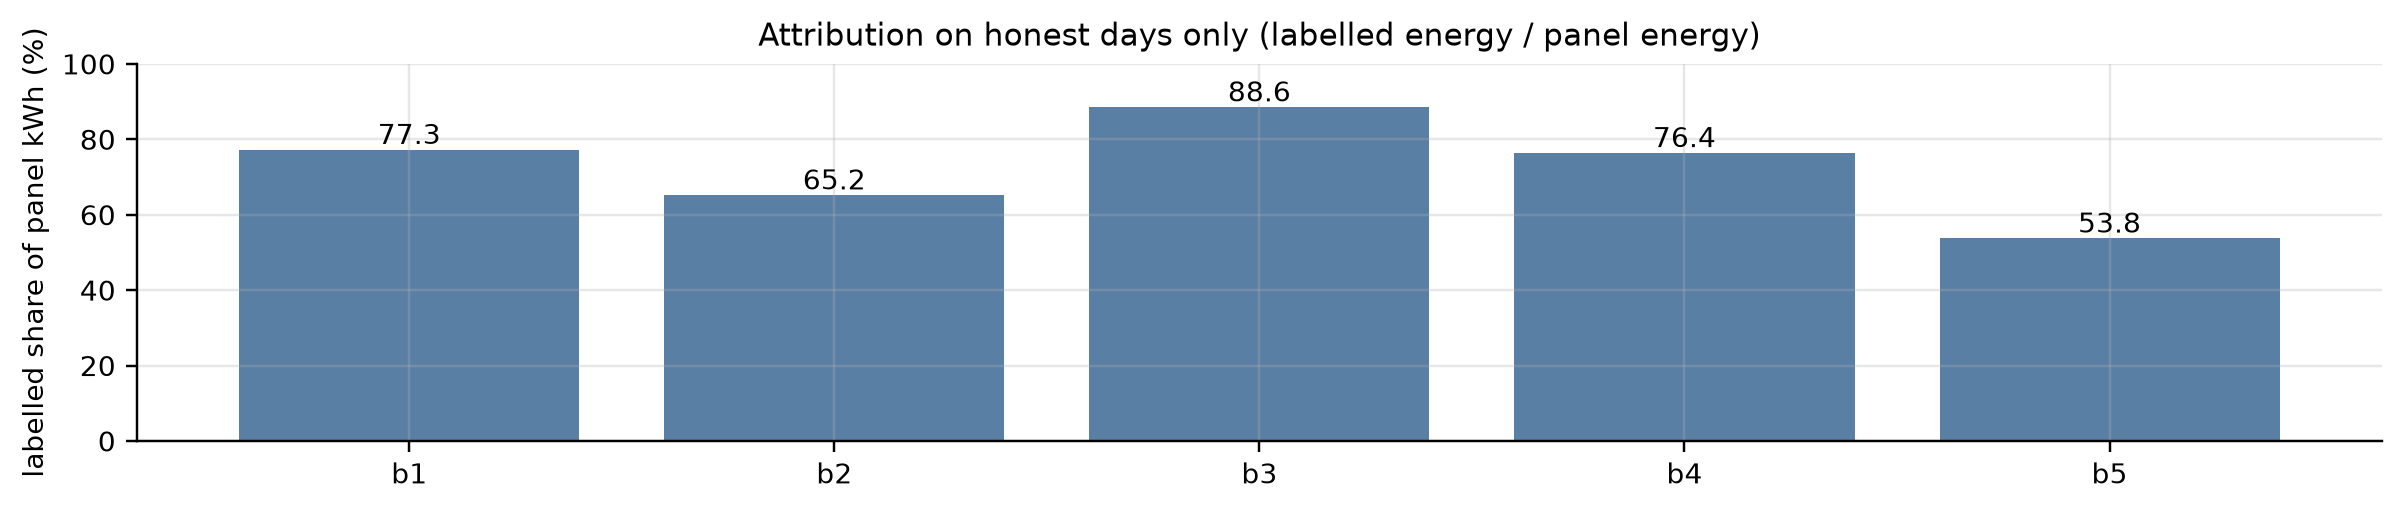

In [ ]:
import matplotlib.pyplot as _plt2

_fig, _ax = _plt2.subplots(figsize=(11, 2.4))
_ks = list(attr_pct.keys())
_vs = [attr_pct[k] for k in _ks]
_ax.bar(_ks, _vs, color="#5a7fa5")
for _i, _vv in enumerate(_vs):
    _ax.text(_i, _vv + 1.5, "%.1f" % _vv, ha="center", fontsize=9)
_ax.set_ylim(0, 100)
_ax.set_ylabel("labelled share of panel kWh (%)")
_ax.set_title("Attribution on honest days only (labelled energy / panel energy)")
_fig = _plt2.gcf()
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** Building 1 — the flagship — explains **77.3%** of its panel energy on its
14 honest days (99.1 of 128.2 kWh); building 2 reaches **65.2%** (49.4 of 75.8). The
missing share is not measurement error: b1's unexplained 22.7% is dominated by the
1.6 kW mystery circuit m12's unnamed load plus whatever the sockets feed, and a chunk
of it is the **apparent-vs-real-power** caveat — REDD records power as the meters saw
it, and panel-vs-circuit power factors do not cancel exactly. The star of the table is
the row that cannot compute: **b6 has no honest panel day at all**, so the question "how
much of this house do the labels explain?" is *unaskable* there — no amount of clever
resampling fixes a recorder that never assembled a full day. And b5's footnote matters
twice over: two of its "labelled circuits" are **subpanels** (m10, m11), which hold
2.7 of its 16.0 kWh — including them in an appliance sum double-counts whatever those
distribution boards feed. [collectable] Every attribution number we publish should
carry its honest-day count; "b1: 77.3% over 14 days" is a claim, "b1: 77.3%" is a
rumour. [insight only] Compare 01's UK-DALE additivity checks and 02's REFIT
house-level energy share: REDD sits in the same 65-80% band, so a ~1/4 unexplained
base is the *norm* for submetered homes, not a REDD defect.

## Q9 — Simultaneity: how often are appliances ON together?

*Question: on 60 s buckets, how many of b1's 18 labelled circuits are ON at once — and
how much of the answer is real physics versus threshold artefacts?*

b1 60 s buckets: 52,235
legacy shares (k ON -> % of buckets): {0: 8.5, 3: 24.6, 4: 39.4, 5: 17.5, 6: 7.8, 7: 0.7, 8: 0.5, 9: 0.5, 10: 0.2, 11: 0.1, 12: 0.0}
legacy two-plus: 91.5%
floor  shares (k ON -> % of buckets): {0: 25.9, 1: 33.8, 2: 20.1, 3: 11.4, 4: 5.7, 5: 1.5, 6: 0.7, 7: 0.4, 8: 0.2, 9: 0.1, 10: 0.0, 11: 0.0}
floor two-plus: 40.3% | empty buckets: 25.9%
conditioned on a non-empty bucket: 1+ 45.6% | 2+ 54.4% | 3+ 15.4%


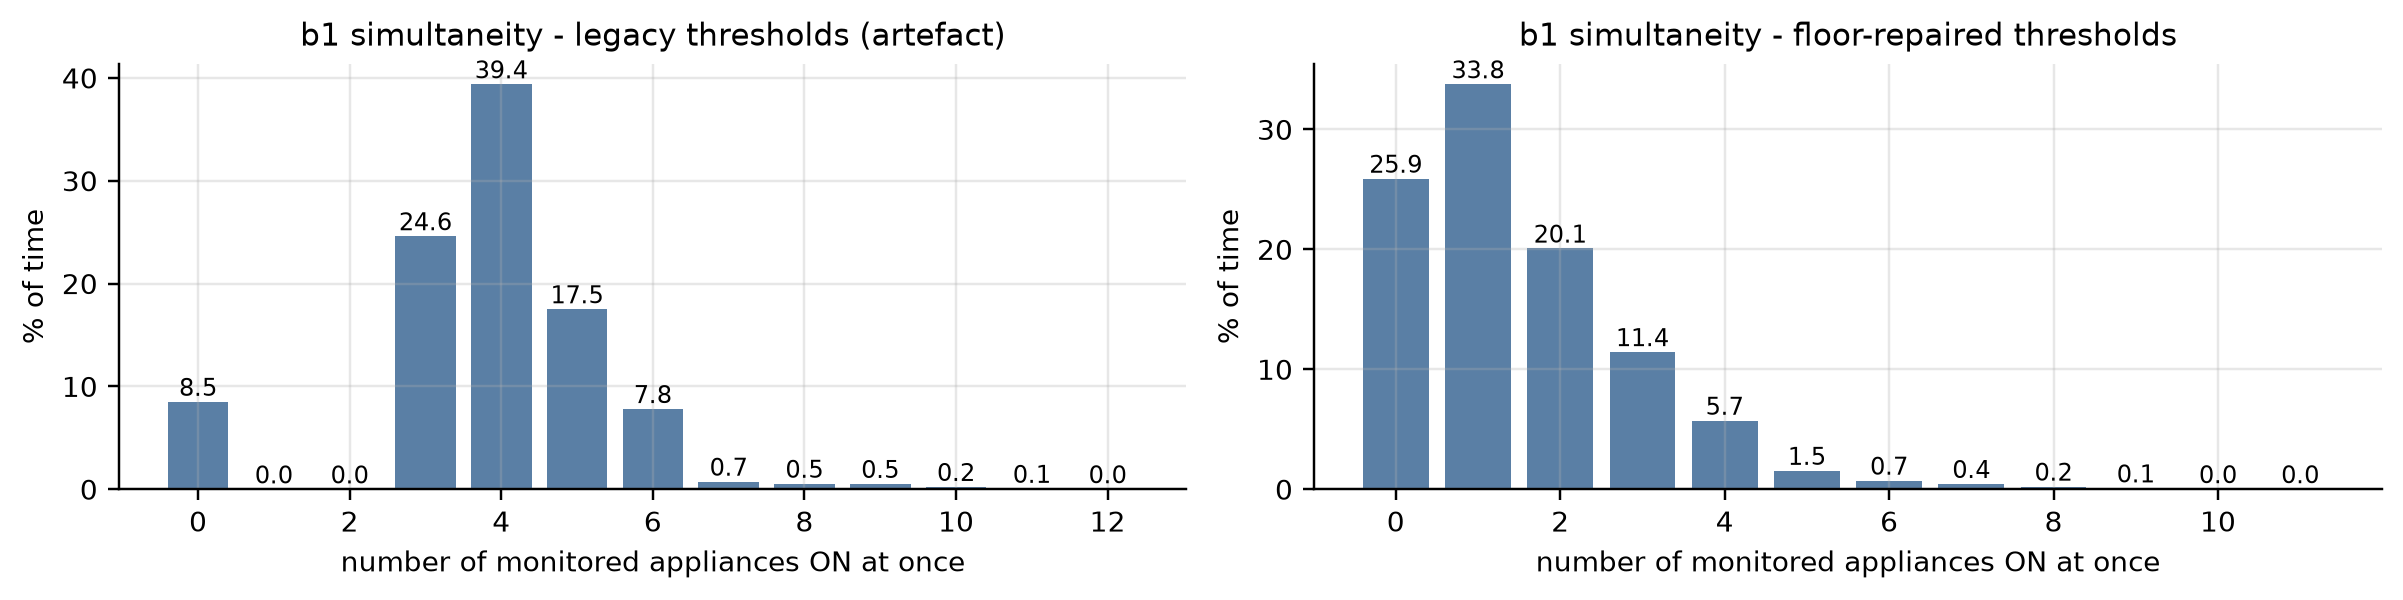

In [ ]:
tsl, _onl_leg, _onl_flr = [], [], []
for (_b, _m), (_ts, _v) in sorted(ch_all.items()):
    if _b != 1:
        continue
    _sl = eda.channel_stats(_ts, _v, missing_values=(), thr_rule="legacy")
    _sf = eda.channel_stats(_ts, _v, missing_values=(), thr_rule="floor")
    tsl.append(_ts)
    _onl_leg.append(_v > float(_sl["thr_on_w"]))
    _onl_flr.append(_v > float(_sf["thr_on_w"]))
sim_leg = eda.simultaneity(tsl, _onl_leg, bucket_s=60)
sim_flr = eda.simultaneity(tsl, _onl_flr, bucket_s=60)
print("b1 60 s buckets: %s" % "{:,}".format(int(sim_leg["n_buckets"])))
print("legacy shares (k ON -> % of buckets):", {k: round(100 * float(vv), 1) for k, vv in sorted(sim_leg["shares"].items())})
print("legacy two-plus: %.1f%%" % (100 * float(sim_leg["two_plus"])))
print("floor  shares (k ON -> % of buckets):", {k: round(100 * float(vv), 1) for k, vv in sorted(sim_flr["shares"].items())})
print("floor two-plus: %.1f%% | empty buckets: %.1f%%" % (100 * float(sim_flr["two_plus"]), 100 * float(sim_flr["shares"].get(0, 0.0))))
_ne = 1.0 - float(sim_flr["shares"].get(0, 0.0))
print("conditioned on a non-empty bucket: 1+ %.1f%% | 2+ %.1f%% | 3+ %.1f%%" % (
    100 * float(sim_flr["shares"].get(1, 0.0)) / _ne,
    100 * float(sim_flr["two_plus"]) / _ne,
    100 * float(sim_flr["shares"].get(3, 0.0)) / _ne))
_fig, _ax = plt.subplots(1, 2, figsize=(11, 2.8))
eda.fig_simultaneity(sim_leg, ax=_ax[0], title="b1 simultaneity - legacy thresholds (artefact)")
eda.fig_simultaneity(sim_flr, ax=_ax[1], title="b1 simultaneity - floor-repaired thresholds")
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** Same artefact as 01's, same fix. Under the legacy rule the b1 histogram
claims appliances are ON together **91.5%** of the time — but that number is
manufactured by the always-ON channels the legacy threshold creates (Q5's degenerate
list: two b1 sockets circuits pinned ON for the whole span). With the floor repair, the
picture is honest: **25.9% of buckets are truly empty** (the house's ~150 W base lives
entirely on unlabelled circuits), one labelled appliance runs about a third of the time,
and **two-plus simultaneity is 40.3%** — two labelled appliances overlap roughly
10 hours a day, mostly fridge-plus-something. Conditioned on anything being ON, 2+
co-occurrence is 54.4%. [collectable] Store simultaneity histograms per building in the
gold layer *only* after threshold repair — the legacy version is not pessimistic, it is
wrong, and it propagates into any disaggregation prior built on it. [insight only]
Cross-check with 01: UK-DALE's floor-repaired two-plus was in the same band, so
"two things running at once" is the steady state of a normal home, not a peak event.

## Q10 — What the gold layer should remember from REDD

*Question: everything this notebook computed the hard way — which parts belong in
metadata, computed once, so no notebook ever re-derives them?*

fridge                123.8 kWh (whole corpus, capped integrals)
dishwasher             31.6 kWh (whole corpus, capped integrals)
washing_machine        71.0 kWh (whole corpus, capped integrals)
microwave              26.5 kWh (whole corpus, capped integrals)
other labelled        526.6 kWh (whole corpus, capped integrals)
dead (<0.5 kWh)         3.9 kWh (whole corpus, capped integrals)


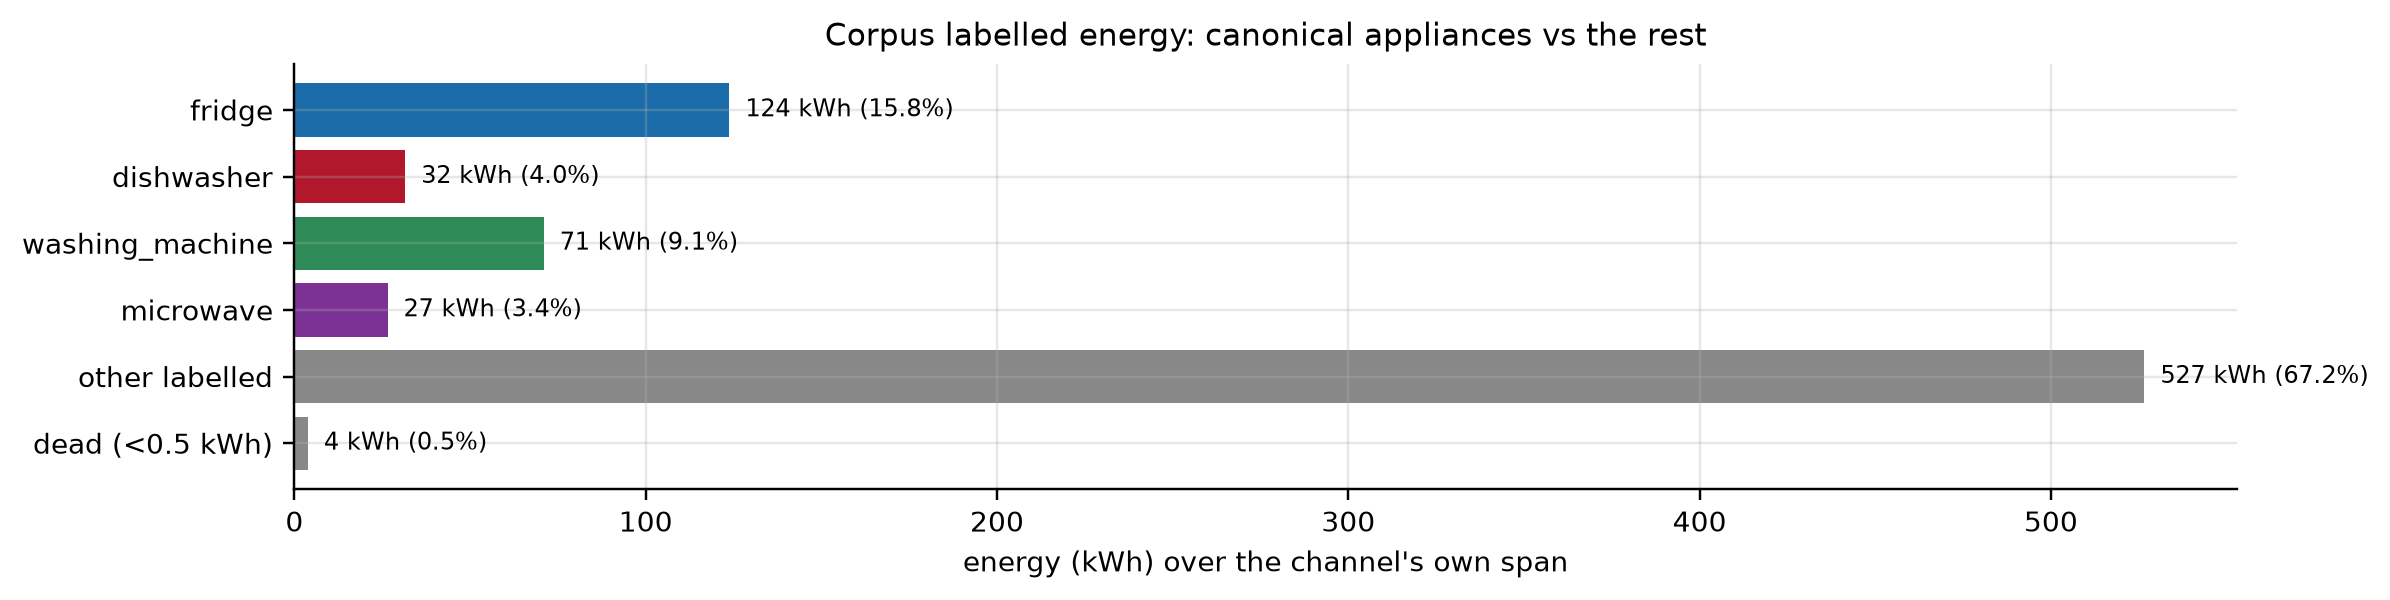

In [ ]:
_groups = {"fridge": 0.0, "dishwasher": 0.0, "washing_machine": 0.0, "microwave": 0.0}
_other = 0.0
_dead = 0.0
for _r in inv.itertuples():
    if _r.kwh_cap30 < 0.5:
        _dead += float(_r.kwh_cap30)
    elif _r.canonical in _groups:
        _groups[_r.canonical] += float(_r.kwh_cap30)
    else:
        _other += float(_r.kwh_cap30)
_items = [(_k, _v, eda.canon_color(_k)) for _k, _v in _groups.items()] + [("other labelled", _other, eda.canon_color("other labelled")), ("dead (<0.5 kWh)", _dead, eda.canon_color("dead"))]
for _k, _v, _c in _items:
    print("%-18s %8.1f kWh (whole corpus, capped integrals)" % (_k, _v))
_fig, _ax = plt.subplots(figsize=(11, 2.8))
eda.fig_energy_share(_items, ax=_ax, title="Corpus labelled energy: canonical appliances vs the rest")
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** The corpus's labelled energy is a **cold-chain story**: the five
fridges dominate the canonical total (123.8 kWh of continuous compressor work), the
nine washer/dryer meters come second (71.0 kWh — the 2.9 kW elements doing the work
in half the homes), dishwashers third (31.6), microwaves a rounding error (26.5). The
"other labelled" bar is the fine print from Q4 — sockets, lights,
furnaces and the two b5 subpanels — and the "dead" slice is 28% of channels contributing
almost nothing. What the gold layer should carry, computed once: the canonical map
(already in `appliance_map_redd.json`), the threshold rule with its 5 W floor
(`thresholds.json`), a **dead flag** per channel (Q4), **leg assignments and 240 V
flags** for b1 (Q2), **per-building cadence** (Q1), **honest-day counts and paired
coverage** per building (Q3), and the **good_sections decode rule** (µs starts, ns-or-µs
ends). None of that is a statistic; all of it is *identity* — the things that silently
change every downstream number when they are wrong. [collectable] This is the exact
metadata contract the Shelly deployment needs from day one; REDD is where we learned
each item the expensive way.

## Quirks & gotchas

1. **Two recorders, two clocks, one house.** The 1 s panel and the 3-4 s circuit
   recorder fail independently; only 50.3% of b1's circuit supervision happens under a
   watching panel. Never trust a "36-day ground truth" claim that ignores the mask.
2. **The cadence spec was 3 s; half the homes recorded 4 s.** b2/b3/b6 vs b1/b4/b5 —
   any constant-cadence assumption is wrong by a third for half the corpus.
3. **good_sections mixes units**: starts in microseconds, ends in nanoseconds, one
   (start, end) pair repeated 26 times, claiming 36.27 days of continuity for a meter
   that covered 49.8% of its span. Decode with the us/ns rule or reconstruct fiction.
4. **The dropout cache measures against a 1 Hz yardstick**: 22.0% "missing" for a 4 s
   channel that is 95.2% complete on its own cadence. Yardstick matters.
5. **The uncapped integral invents energy**: 341.3 vs 167.7 kWh on b1's panel — 173.6
   kWh of phantom load bridged across the outages. Cap the dt, always.
6. **The stove never cooked under a watching panel**: 61 ON events on circuit m14, zero
   in a panel-covered minute. A whole appliance, absent from the aggregate record.
7. **m12 is a 1.6 kW mystery** sitting on leg A with a "unknown" label; eight unknown
   circuits corpus-wide. Someone knew in 2011.
8. **29 of 104 labelled circuits are dead** (< 0.5 kWh); b5's two "washer dryer" meters
   never ran; b6's dishwasher never ran; b4 has no fridge; nobody owns a kettle.
9. **b5's "labelled circuits" include two subpanels** (m10, m11) — summing labelled
   circuits there inflates the appliance-energy sum by a fifth.
10. **5 channels are always-ON under the legacy threshold**; the 5 W floor repair is
    not optional. And the diurnal crest is 18:00 **EDT** — timestamps are UTC; the
    offset is -4 for this span, not the -0/+1 of the UK corpora.

## Verdict — what is this dataset good for?

REDD is the **heritage reference**: the 2011 template every later corpus copied, and
still the cleanest public lab for **split-phase physics** — the paired 1 s panel over
submeters is where inrush transients, the free 240 V joint detector, leg assignments
and the mystery-load problem can all be *demonstrated* rather than asserted. Its
supervision pool (50.3% of b1 minutes; 14 honest days) is small but real, and its
attribution band (65-77%) calibrates expectations for every submetered home since.

It is **not** the corpus for: long-horizon behaviour (weeks, not years), UK demand
culture (no kettle, gas-heat homes, AC and furnaces instead), or day-level attribution
(b6 cannot answer; b5 barely exists at the panel). Its metadata cannot be trusted —
caches, cadences and labels all need the re-derivation treatment this notebook applied
— but its *series*, once decoded honestly, still teach things 01 and 02 cannot: what a
240 V appliance looks like from the service entrance, and what a one-second story
looks like from inside a four-second one.

Use it as the physics reference for the Shelly campaign's appliance profiles: inrush
magnitudes for motor loads, element duty cycles for dryers and ovens, the fridge's
18-runs-a-day cadence, and the ~1/4 unexplained base that every honest attribution
must budget for.

In [ ]:
_apps = []
for (_b, _m) in [(1, 5), (1, 6), (1, 10), (1, 11), (1, 20)]:
    _info = amap["redd"]["building_1"]["meters"][str(_m)]
    _ts, _v = ch_all[(_b, _m)]
    _stf = eda.channel_stats(_ts, _v, missing_values=(), thr_rule="floor")
    _kwh = eda.kwh_of(_ts, _v, missing_values=(), dt_cap_s=30.0)
    _apps.append([_info["label"] + " (m%d)" % _m, round(float(_stf["p50_on_w"]), 1), round(float(_stf["thr_on_w"]), 1),
                 round(100 * float(_stf["on_share"]), 1), round(float(_kwh), 1),
                 round(float(_stf["episodes_per_day"]), 1), round(float(_stf.get("dwell_p50_s", float("nan"))), 0)])
SUMMARY = {
    "dataset": "REDD (FND extract)",
    "rows": 56_341_629,
    "span_days": round(float(scan_b1["span_days"]), 1),
    "cadence_s": 1.0,
    "aggregate": {
        "mean_w": round(float(scan_b1["mean_w"]), 1),
        "p50_w": round(float(scan_b1["quantiles"]["p50"]), 1),
        "p95_w": round(float(scan_b1["quantiles"]["p95"]), 1),
        "energy_kwh": round(float(kwh_capped), 1),
    },
    "simultaneity_two_plus_pct": {"legacy_thresholds": round(100 * float(sim_leg["two_plus"]), 1),
                                  "floor_repaired": round(100 * float(sim_flr["two_plus"]), 1)},
    "role": "heritage reference: split-phase paired panel+submeter lab (1 s panel, 3-4 s circuits, 2011 sprint); "
            "b1 honest-day supervision pool 50.3%, attribution 77.3% over 14 honest days",
    "appliances": _apps,
}
mo.md(eda.md_summary(SUMMARY))

**Summary**

| metric | value |
| --- | --- |
| dataset | REDD (FND extract) |
| rows | 56,341,629 |
| span | 36.3 days |
| cadence | 1.00 s |
| power W (mean / p50 / p95) | 384.0 / 176.3 / 1263.9 |
| energy | 167.7 kWh |
| simultaneity (2+ ON) - legacy thresholds | 91.5% of 60 s buckets |
| simultaneity (2+ ON) - floor repaired | 40.3% of 60 s buckets |
| role | heritage reference: split-phase paired panel+submeter lab (1 s panel, 3-4 s circuits, 2011 sprint); b1 honest-day supervision pool 50.3%, attribution 77.3% over 14 honest days |

Appliances:

| label | p50_on_W | thr_on_W | duty_% | kWh | eps/day | dwell_p50_s |
| --- | --- | --- | --- | --- | --- | --- |
| fridge (m5) | 192.0 | 99.0 | 25.8 | 44.7 | 17.8 | 1096.0 |
| dish washer (m6) | 394.0 | 197.0 | 3.6 | 19.9 | 9.3 | 176.0 |
| washer dryer (m10) | 411.0 | 205.5 | 0.9 | 3.5 | 1.7 | 432.0 |
| microwave (m11) | 1506.0 | 755.0 | 1.1 | 16.9 | 12.1 | 60.0 |
| washer dryer (m20) | 2710.0 | 1355.0 | 1.3 | 29.2 | 7.3 | 128.0 |

<details><summary>raw JSON (machine-readable)</summary>

```json
{
  "dataset": "REDD (FND extract)",
  "rows": 56341629,
  "span_days": 36.3,
  "cadence_s": 1.0,
  "aggregate": {
    "mean_w": 384.0,
    "p50_w": 176.3,
    "p95_w": 1263.9,
    "energy_kwh": 167.7
  },
  "simultaneity_two_plus_pct": {
    "legacy_thresholds": 91.5,
    "floor_repaired": 40.3
  },
  "role": "heritage reference: split-phase paired panel+submeter lab (1 s panel, 3-4 s circuits, 2011 sprint); b1 honest-day supervision pool 50.3%, attribution 77.3% over 14 honest days",
  "appliances": [
    [
      "fridge (m5)",
      192.0,
      99.0,
      25.8,
      44.7,
      17.8,
      1096.0
    ],
    [
      "dish washer (m6)",
      394.0,
      197.0,
      3.6,
      19.9,
      9.3,
      176.0
    ],
    [
      "washer dryer (m10)",
      411.0,
      205.5,
      0.9,
      3.5,
      1.7,
      432.0
    ],
    [
      "microwave (m11)",
      1506.0,
      755.0,
      1.1,
      16.9,
      12.1,
      60.0
    ],
    [
      "washer dryer (m20)",
      2710.0,
      1355.0,
      1.3,
      29.2,
      7.3,
      128.0
    ]
  ]
}
```

</details>

## Provenance

- **Source dataset**: J. Zico Kolter and Matthew J. Johnson, *REDD: A public data set
  for energy disaggregation research*, SustKDD workshop, 2011 (MIT).
- **In this repo**: `data/fnd/redd/` — parquet conversion of
  `data/raw/redd/redd.h5` by `src/pipelines/01_extract_dataset/extract_redd.py`;
  the HDF5 intermediate is NILMTK's layout (Nipun Batra et al., *NILMTK: an open
  source toolkit for NILM*, e-Energy 2014).
- **Labels**: `data/gold/appliance_map_redd.json` (per-building meter -> raw label ->
  canonical); **thresholds**: `data/gold/thresholds.json` (half-median rule; the 5 W
  floor repair is Q5).
- **Clock convention**: timestamps stored in UTC microseconds; the span's local offset
  is UTC-4 (US EDT) — every diurnal plot here uses it. See 02b for the cross-dataset
  clock audit.
- **Cross-references**: 01 UK-DALE (threshold rule, kettle inrush), 02 REFIT (cache
  autopsy, attribution band), 04 ECO and 05 GREEND (low-frequency European corpora).
- Notebook authored in marimo; every number is computed from the parquet series at
  render time.